### First attempt

In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
# train_dataset.data[2]

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report
import numpy as np
import torch
import os

os.environ["WANDB_LOG_MODEL"] = "checkpoint"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset splits
train_dataset = load_dataset("LabHC/bias_in_bios", split="train")
valid_dataset = load_dataset("LabHC/bias_in_bios", split="dev")
test_dataset = load_dataset("LabHC/bias_in_bios", split="test")

# Identify number of unique professions (already encoded as int)
num_labels = len(set(train_dataset["profession"]))

# Tokenization
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize_function(example):
    return tokenizer(example["hard_text"], truncation=True, padding="max_length", max_length=256)

train_dataset = train_dataset.map(tokenize_function, batched=True)
valid_dataset = valid_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set the label field
train_dataset = train_dataset.rename_column("profession", "label")
valid_dataset = valid_dataset.rename_column("profession", "label")
test_dataset = test_dataset.rename_column("profession", "label")

# Set format for PyTorch
columns = ["input_ids", "attention_mask", "label"]
train_dataset.set_format(type="torch", columns=columns)
valid_dataset.set_format(type="torch", columns=columns)
columns = ["input_ids", "attention_mask", "label", "gender"]
test_dataset.set_format(type="torch", columns=columns)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels)
model.to(device)

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    report = classification_report(labels, predictions, output_dict=True)
    # Optionally return average F1 across all classes
    return {
        "macro_f1": report["macro avg"]["f1-score"],
        "accuracy": report["accuracy"]
    }

training_args = TrainingArguments(
    output_dir="./biased_resume_model_04",
    do_train=True,
    do_eval=True,
    eval_strategy="steps",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./biased_resume_logs_04",
    logging_steps=10000,
    save_steps=5000,
    eval_steps=2500,
    save_total_limit=2,
    report_to="wandb",  # Logs metrics and artifacts to W&B
    run_name="bias-in-bios-distilbert-04",
    load_best_model_at_end=True,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# Train
trainer.train()

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.30k [00:00<?, ?B/s]

(…)-00000-of-00001-0ab65b32c47407e8.parquet:   0%|          | 0.00/64.9M [00:00<?, ?B/s]

(…)-00000-of-00001-5598c840ce8de1ee.parquet:   0%|          | 0.00/24.9M [00:00<?, ?B/s]

...

Step,Training Loss,Validation Loss,Macro F1,Accuracy
2500,No log,0.548101,0.770450,0.835780
5000,No log,0.506772,0.789073,0.845492
7500,No log,0.501644,0.797819,0.848772
10000,0.562200,0.489522,0.802759,0.854876
12500,0.562200,0.483869,0.806406,0.855053
15000,0.562200,0.474141,0.809193,0.859190
17500,0.562200,0.478948,0.814199,0.860855
20000,0.371600,0.484581,0.813548,0.860905
22500,0.371600,0.484442,0.814280,0.861637


wandb: Adding directory to artifact (./biased_resume_model_04/checkpoint-5000)... Done. 12.6s
wandb: Adding directory to artifact (./biased_resume_model_04/checkpoint-10000)... Done. 5.6s
wandb: Adding directory to artifact (./biased_resume_model_04/checkpoint-15000)... Done. 15.9s
wandb: Adding directory to artifact (./biased_resume_model_04/checkpoint-20000)... Done. 5.7s


Step,Training Loss,Validation Loss,Macro F1,Accuracy
2500,No log,0.548101,0.770450,0.835780
5000,No log,0.506772,0.789073,0.845492
7500,No log,0.501644,0.797819,0.848772
10000,0.562200,0.489522,0.802759,0.854876
12500,0.562200,0.483869,0.806406,0.855053
15000,0.562200,0.474141,0.809193,0.859190
17500,0.562200,0.478948,0.814199,0.860855
20000,0.371600,0.484581,0.813548,0.860905
22500,0.371600,0.484442,0.814280,0.861637


wandb: Adding directory to artifact (./biased_resume_model_04/checkpoint-24141)... Done. 15.1s


TrainOutput(global_step=24141, training_loss=0.4399674778514767, metrics={'train_runtime': 19239.5715, 'train_samples_per_second': 40.148, 'train_steps_per_second': 1.255, 'total_flos': 5.118488336045261e+16, 'train_loss': 0.4399674778514767, 'epoch': 3.0})

### Train again

## pick up model from wandb and predict

In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
import wandb
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from sklearn.metrics import classification_report
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report
import numpy as np
import torch
import os


wandb.init()
# Use your run and checkpoint name
artifact = wandb.use_artifact("kina19131-ibm/huggingface/model-bias-in-bios-distilbert-04:v6", type="model")
artifact_dir = artifact.download()

# Load the model from the artifact directory
model = AutoModelForSequenceClassification.from_pretrained(artifact_dir)

wandb: Currently logged in as: kina19131 (kina19131-ibm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Downloading large artifact model-bias-in-bios-distilbert-04:v6, 256.41MB. 8 files... 
wandb:   8 of 8 files downloaded.  
Done. 0:0:1.1 (241.3MB/s)


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Step 1: Get predictions
preds_output = trainer.predict(test_dataset)
logits = preds_output.predictions
labels = preds_output.label_ids
preds = np.argmax(logits, axis=-1)

# Step 2: Get gender labels
gender_labels = test_dataset["gender"]  # Assuming it's in the dataset

# Step 3: Bias-aware evaluation
df = pd.DataFrame({
    "true": labels,
    "pred": preds,
    "gender": gender_labels
})

report = classification_report(labels, preds, output_dict=True, zero_division=0)
metrics = {
    "accuracy": report["accuracy"],
    "macro_f1": report["macro avg"]["f1-score"]
}

for gender in df["gender"].unique():
    gender_df = df[df["gender"] == gender]
    g_report = classification_report(gender_df["true"], gender_df["pred"], output_dict=True, zero_division=0)
    metrics[f"f1_gender_{gender}"] = g_report["macro avg"]["f1-score"]

# F1 gap
genders = df["gender"].unique()
if len(genders) == 2:
    gap = abs(metrics[f"f1_gender_{genders[0]}"] - metrics[f"f1_gender_{genders[1]}"])
    metrics["f1_gap_between_genders"] = gap

# Print or log
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


accuracy: 0.8611
macro_f1: 0.8125
f1_gender_0: 0.7805
f1_gender_1: 0.7991
f1_gap_between_genders: 0.0186


In [ ]:
pd.crosstab(index=df["gender"], columns=df["pred"], normalize='index')

pred,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
gender,,,,,,,,,,,,,,,,,,,,,
0,0.015038,0.035171,0.099051,0.008053,0.010263,0.022810,0.045115,0.001479,0.005731,0.022548,...,0.076259,0.097178,0.016986,0.306328,0.033054,0.005974,0.026930,0.049909,0.024346,0.001573
1,0.010335,0.011889,0.072211,0.003109,0.002912,0.005321,0.028639,0.020341,0.001073,0.012831,...,0.049330,0.104769,0.019377,0.299242,0.062817,0.000788,0.005868,0.008671,0.047797,0.008649


In [ ]:
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "true": labels,
    "pred": preds,
    "gender": gender_labels
})

rows = []

for prof in sorted(df["true"].unique()):
    row = {"profession": prof}
    for gender in sorted(df["gender"].unique()):
        subset = df[(df["true"] == prof) & (df["gender"] == gender)]
        if len(subset) > 0:
            row[f"f1_gender_{gender}"] = f1_score(
                subset["true"], subset["pred"], average="macro", zero_division=0
            )
        else:
            row[f"f1_gender_{gender}"] = np.nan
    rows.append(row)

f1_matrix = pd.DataFrame(rows)
f1_matrix.set_index("profession", inplace=True)
print(f1_matrix)


            f1_gender_0  f1_gender_1
profession                          
0              0.045534     0.051028
1              0.042349     0.055868
2              0.040301     0.043540
3              0.049565     0.078472
4              0.050763     0.084942
5              0.049664     0.118721
6              0.046546     0.061085
7              0.078632     0.058555
8              0.056250     0.119309
9              0.051625     0.065821
10             0.144144     0.063192
11             0.040710     0.037902
12             0.031646     0.039098
13             0.052083     0.037163
14             0.057345     0.056331
15             0.095745     0.055035
16             0.046580     0.070381
17             0.082227     0.074263
18             0.043656     0.044914
19             0.036768     0.044399
20             0.044917     0.050092
21             0.036902     0.038544
22             0.036809     0.038812
23             0.070194     0.103448
24             0.038936     0.054054
2

In [ ]:
f1_matrix["f1_gap"] = abs(f1_matrix["f1_gender_0"] - f1_matrix["f1_gender_1"])
print(f1_matrix.sort_values("f1_gap", ascending=False).head(10))

            f1_gender_0  f1_gender_1    f1_gap
profession                                    
10             0.144144     0.063192  0.080952
5              0.049664     0.118721  0.069057
8              0.056250     0.119309  0.063059
15             0.095745     0.055035  0.040710
27             0.098765     0.064509  0.034257
4              0.050763     0.084942  0.034180
23             0.070194     0.103448  0.033254
3              0.049565     0.078472  0.028907
16             0.046580     0.070381  0.023801
7              0.078632     0.058555  0.020077


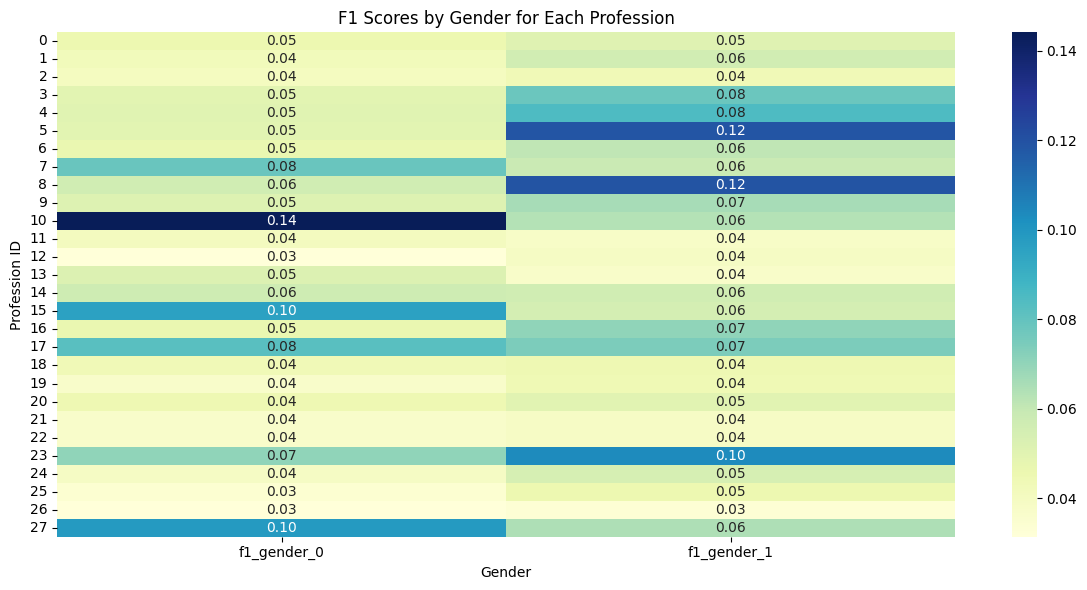

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(f1_matrix[["f1_gender_0", "f1_gender_1"]], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("F1 Scores by Gender for Each Profession")
plt.xlabel("Gender")
plt.ylabel("Profession ID")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report
import numpy as np
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset splits
test_dataset = load_dataset("LabHC/bias_in_bios", split="test")

# Identify number of unique professions (already encoded as int)
num_labels = len(set(test_dataset["profession"]))

# Tokenization
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize_function(example):
    return tokenizer(example["hard_text"], truncation=True, padding="max_length", max_length=256)

test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set the label field
test_dataset = test_dataset.rename_column("profession", "label")

# Set format for PyTorch
columns = ["input_ids", "attention_mask", "label", "gender"]
test_dataset.set_format(type="torch", columns=columns)

def compute_group_confusion_metrics(trainer, test_dataset):
    # Run prediction
    preds_output = trainer.predict(test_dataset)
    logits = preds_output.predictions
    y_pred = np.argmax(logits, axis=1)
    y_true = preds_output.label_ids

    # Extract gender info (ensure 'gender' is in test_dataset before formatting to torch)
    genders = np.array(test_dataset["gender"])

    # Build a DataFrame
    df = pd.DataFrame({
        "y_pred": y_pred,
        "y_true": y_true,
        "gender": genders
    })

    # Group metrics by gender
    metrics = {g: {"TP": 0, "FP": 0, "TN": 0, "FN": 0} for g in np.unique(genders)}

    for gender in metrics:
        subset = df[df["gender"] == gender]
        for _, row in subset.iterrows():
            if row["y_true"] == 1 and row["y_pred"] == 1:
                metrics[gender]["TP"] += 1
            elif row["y_true"] == 0 and row["y_pred"] == 1:
                metrics[gender]["FP"] += 1
            elif row["y_true"] == 0 and row["y_pred"] == 0:
                metrics[gender]["TN"] += 1
            elif row["y_true"] == 1 and row["y_pred"] == 0:
                metrics[gender]["FN"] += 1

    # Convert to DataFrame and compute metrics
    metrics_df = pd.DataFrame(metrics).T
    metrics_df["TPR (Equal Opportunity)"] = metrics_df["TP"] / (metrics_df["TP"] + metrics_df["FN"])
    metrics_df["FPR (Equalized Odds)"] = metrics_df["FP"] / (metrics_df["FP"] + metrics_df["TN"])

    return df, metrics_df

## use

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    report = classification_report(labels, predictions, output_dict=True)
    # Optionally return average F1 across all classes
    return {
        "macro_f1": report["macro avg"]["f1-score"],
        "accuracy": report["accuracy"]
    }

inference_args = TrainingArguments(
    output_dir="./tmp_inference",
    per_device_eval_batch_size=32,
    do_train=False,
    do_eval=False,
    eval_strategy="no",  # ← no evaluation steps; just using the model to predict
    logging_dir="./tmp_logs",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=inference_args,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

df, metrics_df = compute_group_confusion_metrics(trainer, test_dataset)
print(metrics_df)

Using device: cuda


<ipython-input-5-08d87f440653>:96: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


     TP  FP   TN  FN  TPR (Equal Opportunity)  FPR (Equalized Odds)
0  1417  19  680  15                 0.989525              0.027182
1   432   3  396   2                 0.995392              0.007519


In [ ]:
import numpy as np
import pandas as pd

# Demographic Parity Rates (i.e., % predicted as positive)
dp_rates = df.groupby("gender")["y_pred"].mean()

# Disparate Impact
di = dp_rates[1] / dp_rates[0]

# Display
print(f"Demographic Parity Rate (gender=0): {dp_rates[0]:.4f}")
print(f"Demographic Parity Rate (gender=1): {dp_rates[1]:.4f}")
print(f"Disparate Impact (gender=1 / gender=0): {di:.4f}")


Demographic Parity Rate (gender=0): 15.5777
Demographic Parity Rate (gender=1): 16.2277
Disparate Impact (gender=1 / gender=0): 1.0417


#### Archive


In [ ]:
# from transformers import AutoTokenizer
# import matplotlib.pyplot as plt

# tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# # Get lengths of tokenized bios
# lengths = [len(tokenizer(example["hard_text"])["input_ids"]) for example in train_dataset]

# plt.hist(lengths, bins=50)
# plt.xlabel("Number of tokens")
# plt.ylabel("Number of examples")
# plt.title("Token Length Distribution of Hard Texts")
# plt.show()

## attempt 2


In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter
from sklearn.model_selection import train_test_split
import re

# Load dataset
train_dataset_raw = load_dataset("LabHC/bias_in_bios", split="train")
valid_dataset_raw = load_dataset("LabHC/bias_in_bios", split="dev")
test_dataset_raw = load_dataset("LabHC/bias_in_bios", split="test")

# Simple tokenizer (space + punctuation split)
def basic_tokenizer(text):
    return re.findall(r"\b\w+\b", text.lower())

def build_vocab(dataset, tokenizer, min_freq=2):
    from collections import Counter
    counter = Counter()
    for text in dataset["hard_text"]:
        tokens = tokenizer(text)
        counter.update(tokens)

    # Add special tokens
    vocab = {"<pad>": 0, "<unk>": 1}
    idx = 2
    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = idx
            idx += 1
    return vocab

# Build vocab on train split only
vocab = build_vocab(train_dataset_raw, basic_tokenizer)

KeyboardInterrupt: 

In [ ]:
## Convert to indices
def tokens_to_ids(tokens, vocab, max_len=256):
    """
    Map tokens to indices using vocab, truncate/pad to max_len.
    Unknown tokens get index of '<unk>' token.
    """
    unk_id = vocab.get('<unk>', 0)
    pad_id = vocab.get('<pad>', 0)

    ids = [vocab.get(token, unk_id) for token in tokens]

    # Pad or truncate
    if len(ids) < max_len:
        ids += [pad_id] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

class BiosDataset(Dataset):
    def __init__(self, input_ids, labels, texts, genders=None):
        self.input_ids = input_ids
        self.labels = labels
        self.texts = texts
        self.genders = genders

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
            "text": self.texts[idx]  # keep as raw string
        }
        if self.genders is not None:
            item["gender"] = self.genders[idx]
        return item

def process_dataset(raw_dataset, vocab, max_len=256):
    texts = raw_dataset["hard_text"]
    tokenized = [basic_tokenizer(text) for text in texts]
    input_ids = [tokens_to_ids(t, vocab, max_len) for t in tokenized]
    labels = raw_dataset["profession"]
    genders = raw_dataset["gender"] if "gender" in raw_dataset.column_names else None

    return BiosDataset(input_ids=input_ids, labels=labels, texts=texts, genders=genders)

# Preprocess each split
train_dataset_raw_nogender = train_dataset_raw.remove_columns("gender")
valid_dataset_raw_nogender = valid_dataset_raw.remove_columns("gender")

train_dataset = process_dataset(train_dataset_raw_nogender, vocab)
valid_dataset = process_dataset(valid_dataset_raw_nogender, vocab)
test_dataset = process_dataset(test_dataset_raw, vocab)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
import wandb
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        _, h_n = self.gru(x)
        logits = self.fc(h_n.squeeze(0))
        return logits

# 10. Evaluation
def evaluate(model, dataloader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 11. Training setup
num_classes = len(set(train_dataset_raw["profession"]))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GRUClassifier(
    vocab_size=len(vocab),
    embed_dim=100,
    hidden_dim=128,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

wandb.init(
    project="bias_GRU_project", config={
    "learning_rate": 1e-3,
    "epochs": 10,
    "batch_size": train_loader.batch_size,
    "embed_dim": 100,
    "hidden_dim": 128,
    },
)


# 12. Training loop
best_acc = 0.0
for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)
        outputs = model(input_ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_acc = evaluate(model, valid_loader)
    print(f"\nEpoch {epoch + 1}, Loss: {avg_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

    wandb.log({
    "epoch": epoch + 1,
    "train_loss": avg_loss,
    "val_accuracy": val_acc
    })


    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_gru_model.pt")
        print("Best model saved!")
        artifact = wandb.Artifact("best-gru-model", type="model", metadata={"epoch": epoch + 1, "val_accuracy": val_acc})
        artifact.add_file("best_gru_model.pt")
        wandb.log_artifact(artifact)

print("Training complete.")

wandb.finish()


In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader
from tqdm import tqdm

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.eval()
# model.to(device)

def predict_and_compute_bias(model, test_dataset, batch_size=32):
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    all_preds = []
    all_labels = []
    all_genders = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_genders.extend([g.item() if torch.is_tensor(g) else g for g in batch["gender"]])

    # Create DataFrame for per-gender analysis
    df = pd.DataFrame({
        "y_pred": all_preds,
        "y_true": all_labels,
        "gender": all_genders
    })

    # Group metrics by gender
    metrics = {g: {"TP": 0, "FP": 0, "TN": 0, "FN": 0} for g in df["gender"].unique()}

    for gender, group in df.groupby("gender"):
        for _, row in group.iterrows():
            if row["y_true"] == 1 and row["y_pred"] == 1:
                metrics[gender]["TP"] += 1
            elif row["y_true"] == 0 and row["y_pred"] == 1:
                metrics[gender]["FP"] += 1
            elif row["y_true"] == 0 and row["y_pred"] == 0:
                metrics[gender]["TN"] += 1
            elif row["y_true"] == 1 and row["y_pred"] == 0:
                metrics[gender]["FN"] += 1

    # Convert to DataFrame
    metrics_df = pd.DataFrame(metrics).T
    metrics_df["TPR (Equal Opportunity)"] = metrics_df["TP"] / (metrics_df["TP"] + metrics_df["FN"])
    metrics_df["FPR (Equalized Odds)"] = metrics_df["FP"] / (metrics_df["FP"] + metrics_df["TN"])

    return df, metrics_df

# Run it
df2, metrics_df2 = predict_and_compute_bias(model, test_dataset)
print(df2.head())
print(metrics_df2)


In [ ]:
# import numpy as np
# import pandas as pd

# # Demographic Parity Rates (i.e., % predicted as positive)
# dp_rates = df2.groupby("gender")["y_pred"].mean()

# # Disparate Impact
# di = dp_rates[1] / dp_rates[0]

# # Display
# print(f"Demographic Parity Rate (gender=0): {dp_rates[0]:.4f}")
# print(f"Demographic Parity Rate (gender=1): {dp_rates[1]:.4f}")
# print(f"Disparate Impact (gender=1 / gender=0): {di:.4f}")


In [ ]:
def predict_and_compute_bias_per_profession(model, test_dataset, batch_size=32):
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    all_preds = []
    all_labels = []
    all_genders = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_genders.extend([g.item() if torch.is_tensor(g) else g for g in batch["gender"]])

    # Create DataFrame
    df = pd.DataFrame({
        "y_pred": all_preds,
        "y_true": all_labels,
        "gender": all_genders
    })

    profession_gender_metrics = []
    professions = sorted(df["y_true"].unique())

    for profession in professions:
        for gender in df["gender"].unique():
            subset = df[df["gender"] == gender]

            # Binary labels: 1 for this profession, 0 for all others
            y_true_binary = (subset["y_true"] == profession).astype(int)
            y_pred_binary = (subset["y_pred"] == profession).astype(int)

            tp = ((y_true_binary == 1) & (y_pred_binary == 1)).sum()
            fn = ((y_true_binary == 1) & (y_pred_binary == 0)).sum()
            fp = ((y_true_binary == 0) & (y_pred_binary == 1)).sum()
            tn = ((y_true_binary == 0) & (y_pred_binary == 0)).sum()

            tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

            profession_gender_metrics.append({
                "profession": profession,
                "gender": gender,
                "TP": tp,
                "FP": fp,
                "TN": tn,
                "FN": fn,
                "TPR (Equal Opportunity)": tpr,
                "FPR (Equalized Odds)": fpr
            })

    return df, pd.DataFrame(profession_gender_metrics)

df_all_predictions2, metrics_per_profession2 = predict_and_compute_bias_per_profession(model, test_dataset)
print(metrics_per_profession2.head())

Evaluating: 100%|██████████| 3096/3096 [00:09<00:00, 328.21it/s]


   profession  gender    TP    FP     TN   FN  TPR (Equal Opportunity)  \
0           0       0   564   282  52223  328                 0.632287   
1           0       1   365   171  44984  152                 0.705996   
2           1       0  1237  1018  50450  692                 0.641265   
3           1       1   363   284  44789  236                 0.606010   
4           2       0  4355   768  47604  670                 0.866667   

   FPR (Equalized Odds)  
0              0.005371  
1              0.003787  
2              0.019779  
3              0.006301  
4              0.015877  


In [ ]:
metrics_per_profession2.drop(columns=["TP", "FP", "TN", "FN"])

,profession,gender,TPR (Equal Opportunity),FPR (Equalized Odds)
0,0,0,0.632287,0.005371
1,0,1,0.705996,0.003787
2,1,0,0.641265,0.019779
3,1,1,0.606010,0.006301
4,2,0,0.866667,0.015877
5,2,1,0.842848,0.014288
6,3,0,0.687117,0.002230
7,3,1,0.520000,0.001209
8,4,0,0.617329,0.001930
9,4,1,0.536913,0.000637


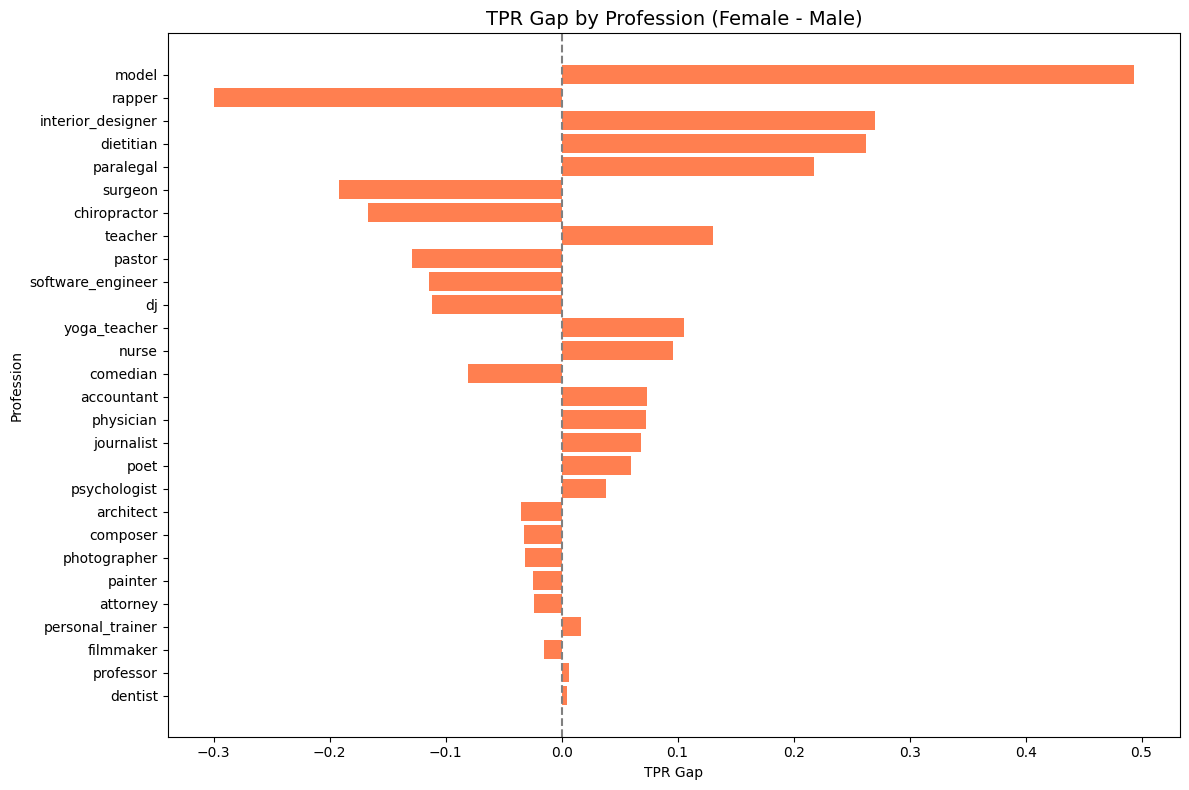

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

id2profession = {
    0: "accountant",
    1: "architect",
    2: "attorney",
    3: "chiropractor",
    4: "comedian",
    5: "composer",
    6: "dentist",
    7: "dietitian",
    8: "dj",
    9: "filmmaker",
    10: "interior_designer",
    11: "journalist",
    12: "model",
    13: "nurse",
    14: "painter",
    15: "paralegal",
    16: "pastor",
    17: "personal_trainer",
    18: "photographer",
    19: "physician",
    20: "poet",
    21: "professor",
    22: "psychologist",
    23: "rapper",
    24: "software_engineer",
    25: "surgeon",
    26: "teacher",
    27: "yoga_teacher"
}

# STEP 2: Drop unneeded columns if not already done
df = metrics_per_profession2.drop(columns=["TP", "FP", "TN", "FN"]).copy()

# STEP 3: Map profession names
df["profession_name"] = df["profession"].map(id2profession)

# STEP 4: Pivot so we can compute gender gaps
pivot = df.pivot(index="profession", columns="gender")

# Flatten MultiIndex columns
pivot.columns = ['_'.join(map(str, col)) for col in pivot.columns]
pivot.reset_index(inplace=True)

# STEP 5: Compute gaps
pivot["TPR_gap"] = pivot["TPR (Equal Opportunity)_1"] - pivot["TPR (Equal Opportunity)_0"]
pivot["FPR_gap"] = pivot["FPR (Equalized Odds)_1"] - pivot["FPR (Equalized Odds)_0"]
pivot["profession_name"] = pivot["profession"].map(id2profession)

# STEP 6: Sort by TPR gap magnitude
pivot_sorted = pivot.sort_values(by="TPR_gap", key=abs, ascending=False)

# STEP 7: Plot TPR gap
plt.figure(figsize=(12, 8))
plt.barh(pivot_sorted["profession_name"], pivot_sorted["TPR_gap"], color='coral')
plt.axvline(0, color='gray', linestyle='--')
plt.title("TPR Gap by Profession (Female - Male)", fontsize=14)
plt.xlabel("TPR Gap")
plt.ylabel("Profession")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


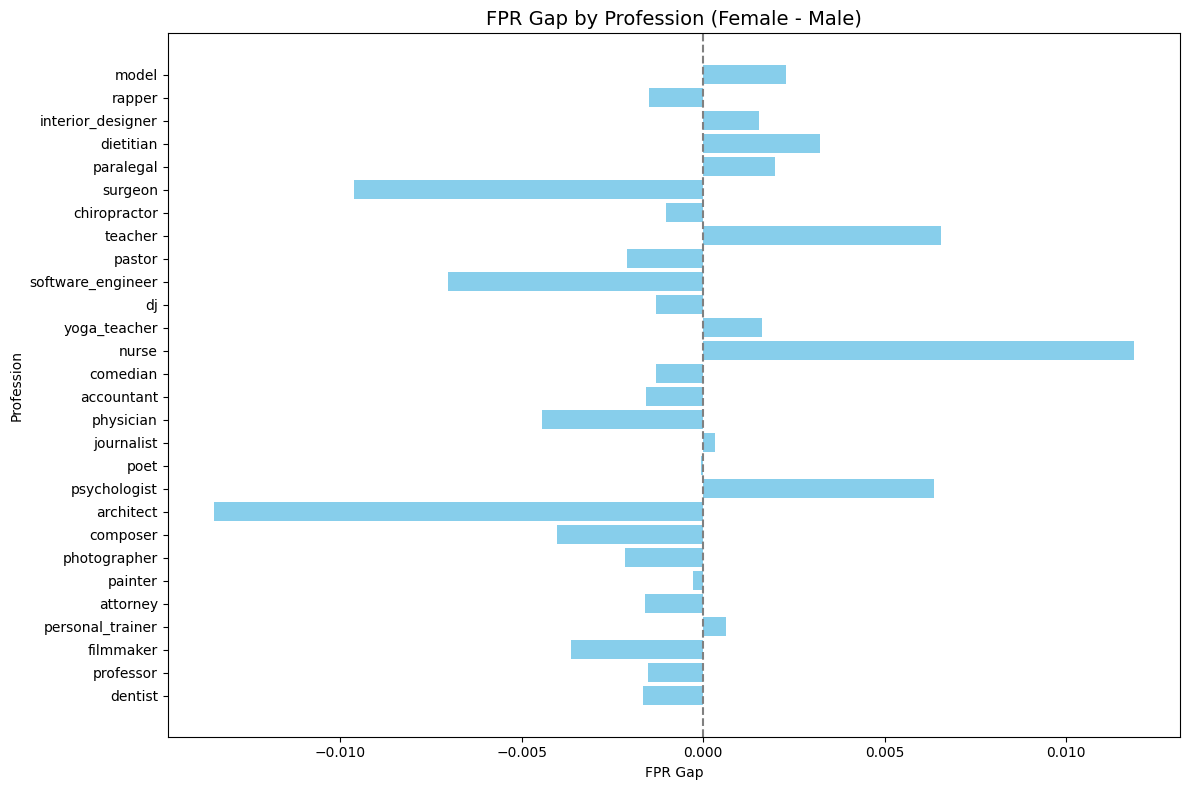

In [ ]:
# Plot FPR gap
plt.figure(figsize=(12, 8))
plt.barh(pivot_sorted["profession_name"], pivot_sorted["FPR_gap"], color='skyblue')
plt.axvline(0, color='gray', linestyle='--')
plt.title("FPR Gap by Profession (Female - Male)", fontsize=14)
plt.xlabel("FPR Gap")
plt.ylabel("Profession")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


| Metric      | High Gap Means...                                                                                                                                                      |
| ----------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **TPR Gap** | One gender is **more likely to be correctly identified** as having a certain profession. A large gap indicates **disparate treatment in recall**.                      |
| **FPR Gap** | One gender is **more likely to be falsely predicted** as having a certain profession. A high FPR gap suggests **over-association** of that gender with the profession. |


## Final : Classifier + Adversary

In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter
from sklearn.model_selection import train_test_split
import re

# Load dataset
train_dataset_raw = load_dataset("LabHC/bias_in_bios", split="train")
valid_dataset_raw = load_dataset("LabHC/bias_in_bios", split="dev")
test_dataset_raw = load_dataset("LabHC/bias_in_bios", split="test")

# Simple tokenizer (space + punctuation split)
def basic_tokenizer(text):
    return re.findall(r"\b\w+\b", text.lower())

def build_vocab(dataset, tokenizer, min_freq=2):
    from collections import Counter
    counter = Counter()
    for text in dataset["hard_text"]:
        tokens = tokenizer(text)
        counter.update(tokens)

    # Add special tokens
    vocab = {"<pad>": 0, "<unk>": 1}
    idx = 2
    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = idx
            idx += 1
    return vocab

# Build vocab on train split only
vocab = build_vocab(train_dataset_raw, basic_tokenizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.30k [00:00<?, ?B/s]

(…)-00000-of-00001-0ab65b32c47407e8.parquet:   0%|          | 0.00/64.9M [00:00<?, ?B/s]

(…)-00000-of-00001-5598c840ce8de1ee.parquet:   0%|          | 0.00/24.9M [00:00<?, ?B/s]

(…)-00000-of-00001-e6551072fff26949.parquet:   0%|          | 0.00/9.95M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/257478 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/99069 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/39642 [00:00<?, ? examples/s]

In [ ]:
id2profession = {
    0: "accountant",
    1: "architect",
    2: "attorney",
    3: "chiropractor",
    4: "comedian",
    5: "composer",
    6: "dentist",
    7: "dietitian",
    8: "dj",
    9: "filmmaker",
    10: "interior_designer",
    11: "journalist",
    12: "model",
    13: "nurse",
    14: "painter",
    15: "paralegal",
    16: "pastor",
    17: "personal_trainer",
    18: "photographer",
    19: "physician",
    20: "poet",
    21: "professor",
    22: "psychologist",
    23: "rapper",
    24: "software_engineer",
    25: "surgeon",
    26: "teacher",
    27: "yoga_teacher"
}

In [ ]:
## Convert to indices
def tokens_to_ids(tokens, vocab, max_len=256):
    """
    Map tokens to indices using vocab, truncate/pad to max_len.
    Unknown tokens get index of '<unk>' token.
    """
    unk_id = vocab.get('<unk>', 0)
    pad_id = vocab.get('<pad>', 0)

    ids = [vocab.get(token, unk_id) for token in tokens]

    # Pad or truncate
    if len(ids) < max_len:
        ids += [pad_id] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

class BiosDataset(Dataset):
    def __init__(self, input_ids, labels, texts, genders=None, id2profession=None):
        self.input_ids = input_ids
        self.labels = labels
        self.texts = texts
        self.genders = genders
        self.id2profession = id2profession  # new

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        label_id = self.labels[idx]
        item = {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "label": torch.tensor(label_id, dtype=torch.long),
            "text": self.texts[idx]
        }
        if self.genders is not None:
            item["gender"] = self.genders[idx]
        if self.id2profession is not None:
            item["profession"] = self.id2profession[int(label_id)]  # map to string
        return item
def process_dataset(raw_dataset, vocab, id2profession=None, max_len=256):
    texts = raw_dataset["hard_text"]
    tokenized = [basic_tokenizer(text) for text in texts]
    input_ids = [tokens_to_ids(t, vocab, max_len) for t in tokenized]
    labels = raw_dataset["profession"]
    genders = raw_dataset["gender"] if "gender" in raw_dataset.column_names else None

    return BiosDataset(
        input_ids=input_ids,
        labels=labels,
        texts=texts,
        genders=genders,
        id2profession=id2profession  # pass mapping here
    )

# Preprocess each split
train_dataset_raw_nogender = train_dataset_raw.remove_columns("gender")
valid_dataset_raw_nogender = valid_dataset_raw.remove_columns("gender")

train_dataset = process_dataset(train_dataset_raw, vocab, id2profession=id2profession)
valid_dataset = process_dataset(valid_dataset_raw, vocab, id2profession=id2profession)
test_dataset = process_dataset(test_dataset_raw, vocab, id2profession=id2profession)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
print(train_dataset[0])

{'input_ids': tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  5, 13, 14, 15, 16, 17,  2,
        18, 19, 20, 21, 22, 23, 24, 25, 26,  5, 27,  8, 28, 29, 30,  2,  3,  4,
        31, 32, 33, 34, 35,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0

In [ ]:
import numpy as np
def compute_tpr_fpr_by_gender(y_true_prof, y_pred_prof, gender_prof):
    tprs, fprs = {}, {}

    for g in [0, 1]:  # 0=male, 1=female
        mask = (gender_prof == g)
        print(f"[GENDER {g}] Num samples: {np.sum(mask)}")
        if np.sum(mask) == 0:
            tprs[g], fprs[g] = np.nan, np.nan
            continue

        tp = np.sum((y_true_prof[mask] == 1) & (y_pred_prof[mask] == 1))
        fn = np.sum((y_true_prof[mask] == 1) & (y_pred_prof[mask] == 0))
        fp = np.sum((y_true_prof[mask] == 0) & (y_pred_prof[mask] == 1))
        tn = np.sum((y_true_prof[mask] == 0) & (y_pred_prof[mask] == 0))

        print(f"[GENDER {g}] TP: {tp}, FN: {fn}, FP: {fp}, TN: {tn}")

        tprs[g] = tp / (tp + fn + 1e-6)
        fprs[g] = fp / (fp + tn + 1e-6)

    print(f"Computed TPRs: {tprs}, FPRs: {fprs}")
    return tprs, fprs

def compute_equalized_opps(y_true, y_pred, sensitive_attr, id2profession, epoch):
    y_true = y_true.detach().cpu().numpy()
    y_pred = y_pred.detach().cpu().numpy()
    sensitive_attr = sensitive_attr.detach().cpu().numpy()

    stats = []
    class_ids = sorted(id2profession.keys())

    for class_id in class_ids:
        profession_name = id2profession[class_id]

        # Create binary vectors: 1 if sample belongs to this class
        y_true_binary = (y_true == class_id).astype(int)
        y_pred_binary = (y_pred == class_id).astype(int)

        # Compute TPR and FPR by gender
        tprs, fprs = {}, {}

        for g in [0, 1]:  # male=0, female=1
            gender_mask = (sensitive_attr == g)

            if np.sum(gender_mask) == 0:
                tprs[g], fprs[g] = np.nan, np.nan
                continue

            tp = np.sum((y_true_binary[gender_mask] == 1) & (y_pred_binary[gender_mask] == 1))
            fn = np.sum((y_true_binary[gender_mask] == 1) & (y_pred_binary[gender_mask] == 0))
            fp = np.sum((y_true_binary[gender_mask] == 0) & (y_pred_binary[gender_mask] == 1))
            tn = np.sum((y_true_binary[gender_mask] == 0) & (y_pred_binary[gender_mask] == 0))

            tprs[g] = tp / (tp + fn + 1e-6)
            fprs[g] = fp / (fp + tn + 1e-6)

        # Skip if not computable
        if np.isnan(tprs[0]) or np.isnan(tprs[1]) or np.isnan(fprs[0]) or np.isnan(fprs[1]):
            continue

        stats.append({
            "epoch": epoch,
            "profession": profession_name,
            "TPR_male": tprs[0],
            "TPR_female": tprs[1],
            "FPR_male": fprs[0],
            "FPR_female": fprs[1],
            "TPR_diff": abs(tprs[1] - tprs[0]),
            "FPR_diff": abs(fprs[1] - fprs[0]),
            "Odd_gap": abs(tprs[1] - tprs[0]) + abs(fprs[1] - fprs[0]),
            "Odd_previlaged_gender": "female" if (tprs[1] + fprs[1]) > (tprs[0] + fprs[0]) else "male"
        })

    return stats


def compute_equalized_odds(y_true, y_pred, sensitive_attr, id2profession, epoch):
    y_true = y_true.detach().cpu().numpy()
    y_pred = y_pred.detach().cpu().numpy()
    sensitive_attr = sensitive_attr.detach().cpu().numpy()

    stats = []
    class_ids = sorted(id2profession.keys())

    for class_id in class_ids:
        profession_name = id2profession[class_id]

        # Binary ground truth and predictions: 1 if class == current class_id
        y_true_binary = (y_true == class_id).astype(int)
        y_pred_binary = (y_pred == class_id).astype(int)

        tprs, fprs = {}, {}

        for g in [0, 1]:  # male = 0, female = 1
            gender_mask = (sensitive_attr == g)

            if np.sum(gender_mask) == 0:
                tprs[g], fprs[g] = np.nan, np.nan
                continue

            tp = np.sum((y_true_binary[gender_mask] == 1) & (y_pred_binary[gender_mask] == 1))
            fn = np.sum((y_true_binary[gender_mask] == 1) & (y_pred_binary[gender_mask] == 0))
            fp = np.sum((y_true_binary[gender_mask] == 0) & (y_pred_binary[gender_mask] == 1))
            tn = np.sum((y_true_binary[gender_mask] == 0) & (y_pred_binary[gender_mask] == 0))

            tprs[g] = tp / (tp + fn + 1e-6)
            fprs[g] = fp / (fp + tn + 1e-6)

        if np.isnan(tprs[0]) or np.isnan(tprs[1]) or np.isnan(fprs[0]) or np.isnan(fprs[1]):
            continue

        stats.append({
            "epoch": epoch,
            "profession": profession_name,
            "TPR_male": tprs[0],
            "TPR_female": tprs[1],
            "FPR_male": fprs[0],
            "FPR_female": fprs[1],
            "Odd_gap": 0.5*(abs(tprs[1] - tprs[0]) + abs(fprs[1] - fprs[0])),
            "Odd_previlaged_gender": "female" if (tprs[1] + fprs[1]) > (tprs[0] + fprs[0]) else "male"
        })

    return stats

In [ ]:
def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)
            logits, _ = model(input_ids)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)
    return total_loss / total_samples


def evaluate(model, dataloader, device):
    model.eval()
    total_correct = total = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            labels    = batch["label"].to(device,  non_blocking=True)

            logits, _ = model(input_ids)
            preds = logits.argmax(1)
            total_correct += (preds == labels).sum().item()
            total += labels.size(0)

            # free GPU tensor ASAP
            del input_ids, labels, logits, preds
    return total_correct / total

def evaluate_adversary(model, adversary, dataloader, device):
    model.eval(); adversary.eval()
    total_correct = total = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            genders   = batch["gender"].float().to(device)
            labels    = batch["label"].to(device)

            _, h = model(input_ids)
            logits = adversary(h, labels)
            preds = (logits > 0).float()
            total_correct += (preds == genders).sum().item()
            total += genders.size(0)
    return total_correct / total


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import wandb
import random
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from torch.autograd import Function


def median_abs_gap(stats, gap_key):
    gaps = np.array([s[gap_key] for s in stats])
    return np.median(np.abs(gaps)) if len(gaps) > 0 else 0


def set_seed(seed: int = 84) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Gradient Reversal Layer
class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lambda_val):
        ctx.lambda_val = lambda_val
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_val * grad_output, None


def grad_reverse(x, lambda_val):
    return GradReverse.apply(x, lambda_val)


def load_glove(vocab: dict, glove_path='glove.6B.100d.txt') -> torch.Tensor:
    embedding_dim = 100
    embedding_matrix = np.random.uniform(-0.05, 0.05, (len(vocab), embedding_dim)).astype(np.float32)
    try:
        with open(glove_path, 'r', encoding='utf8') as f:
            for line in f:
                tokens = line.strip().split()
                word = tokens[0]
                if word in vocab:
                    embedding_matrix[vocab[word]] = np.array(tokens[1:], dtype=np.float32)
    except FileNotFoundError:
        print(f"Warning: GloVe file '{glove_path}' not found. Using random embeddings.")
    return torch.tensor(embedding_matrix)


class GRUClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_classes: int, pretrained_weights=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_weights is not None:
            self.embedding.weight.data.copy_(pretrained_weights)
            self.embedding.weight.requires_grad = False  # optional freeze

        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids: torch.Tensor):
        x = self.embedding(input_ids)
        _, h_n = self.gru(x)
        # Concatenate last hidden states from both directions (assuming 1 layer)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)
        h = self.norm(h)
        h = self.dropout(h)
        return self.fc(h), h


class Adversary(nn.Module):
    def __init__(self, hidden_dim, adv_hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2 * 3, adv_hidden),  # (256 * 3) = 768
            nn.ReLU(),
            nn.Linear(adv_hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, h, true_labels):
        if true_labels.dim() == 1:
            true_labels = true_labels.unsqueeze(1)
        true_labels = true_labels.float().to(h.device)

        h1 = h * true_labels
        h0 = h * (1.0 - true_labels)
        adv_input = torch.cat([h, h1, h0], dim=1)
        return self.net(adv_input).squeeze(1)


def build_paths_and_tag(lambda_adv: float):
    tag = "baseline" if lambda_adv == 0 else f"adv_{lambda_adv:.2f}"
    gru_path = f"{tag}_gru.pt"
    adv_path = f"{tag}_adv.pt"
    art_name = f"joint_model_{tag}"
    return tag, gru_path, adv_path, art_name


In [ ]:

# You need to define or import these functions based on your code:
# evaluate, evaluate_loss, evaluate_adversary,
# compute_equalized_opps, compute_equalized_odds
# Make sure they return the expected values.

def train(
    model: nn.Module,
    adversary: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    valid_loader: torch.utils.data.DataLoader,
    device: torch.device,
    max_lambda: float = 0.0,
    epochs: int = 10,
    warmup_epochs: int = 5
) -> dict:
    """
    Train GRU + adversary with gradient reversal.
    Saves both components and logs to W&B.
    """

    run = wandb.init(
        project="GRUclf_Adv_0615_night",
        config=dict(
            epochs=epochs,
            batch_size=train_loader.batch_size,
            embed_dim=100,
            hidden_dim=128,
            lambda_adv=max_lambda,
            warmup_epochs=warmup_epochs,
            lr=1e-3,
        )
    )
    tag, gru_path, adv_path, art_name = build_paths_and_tag(max_lambda)

    set_seed(42)
    config = wandb.config

    all_labels = []
    for batch in train_loader:
        all_labels.extend(batch["label"].tolist())
    labels = np.array(all_labels)

    # Compute class weights for classification loss
    class_weights = compute_class_weight(class_weight='balanced',
                                         classes=np.unique(labels),
                                         y=labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    clf_crit = nn.CrossEntropyLoss(weight=class_weights)
    adv_crit = nn.BCEWithLogitsLoss()

    optim_clf = torch.optim.Adam(model.parameters(), lr=config.lr)
    optim_adv = torch.optim.Adam(adversary.parameters(), lr=config.lr)

    best_eo_gap = float('inf')
    patience = 3
    no_improve_epochs = 0

    for epoch in range(epochs):
        lambda_val = min(max_lambda, epoch / warmup_epochs * max_lambda)
        model.train()
        adversary.train()

        tot_clf_loss = tot_adv_loss = 0.0
        tot_clf_ok = tot_adv_ok = tot = 0

        for batch in tqdm(train_loader, desc=f"[{tag}] epoch {epoch + 1}/{epochs}"):
            input_ids = batch["input_ids"].to(device)
            y_clf = batch["label"].to(device)
            y_adv = batch["gender"].float().to(device)

            optim_clf.zero_grad()
            optim_adv.zero_grad()

            logits, h = model(input_ids)
            clf_loss = clf_crit(logits, y_clf)

            if lambda_val == 0:
                with torch.no_grad():
                    gender_logits = adversary(h.detach(), y_clf)
                adv_loss = torch.tensor(0.0, device=device)
                total_loss = clf_loss
            else:
                rev_h = grad_reverse(h, lambda_val)
                gender_logits = adversary(rev_h, y_clf)
                adv_loss = adv_crit(gender_logits, y_adv)
                total_loss = clf_loss + adv_loss

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optim_clf.step()

            if lambda_val > 0:
                torch.nn.utils.clip_grad_norm_(adversary.parameters(), max_norm=5.0)
                optim_adv.step()

            tot += y_clf.size(0)
            tot_clf_loss += clf_loss.item()
            tot_clf_ok += (logits.argmax(1) == y_clf).sum().item()

            if lambda_val > 0:
                tot_adv_loss += adv_loss.item()
                adv_preds = (gender_logits > 0).float()
                tot_adv_ok += (adv_preds == y_adv).sum().item()

        # Validation
        val_acc = evaluate(model, valid_loader, device)
        val_clf_loss = evaluate_loss(model, valid_loader, clf_crit, device)
        val_adv_acc = evaluate_adversary(model, adversary, valid_loader, device)

        # Gather predictions and labels for fairness metrics
        y_true_all, y_pred_all, gender_all, profession_all = [], [], [], []

        model.eval()
        with torch.no_grad():
            for batch in valid_loader:
                input_ids = batch["input_ids"].to(device)
                y_clf = batch["label"].to(device)
                y_gender = batch["gender"].to(device)
                prof = batch["profession"]

                logits, _ = model(input_ids)
                preds = logits.argmax(dim=1)

                y_true_all.append(y_clf)
                y_pred_all.append(preds)
                gender_all.append(y_gender)
                profession_all.extend(prof)

        y_true_all = torch.cat(y_true_all)
        y_pred_all = torch.cat(y_pred_all)
        gender_all = torch.cat(gender_all)

        eopp_stats = compute_equalized_opps(
            y_true=y_true_all,
            y_pred=y_pred_all,
            sensitive_attr=gender_all,
            id2profession=id2profession,
            epoch=epoch + 1
        )

        aggregated_TPR_gap = np.median([
            abs(stat["TPR_female"] - stat["TPR_male"])
            for stat in eopp_stats if not np.isnan(stat["TPR_female"]) and not np.isnan(stat["TPR_male"])
        ])
        print("Equalized Opps Gap (Median):", aggregated_TPR_gap)

        eodd_stats = compute_equalized_odds(
            y_true=y_true_all,
            y_pred=y_pred_all,
            sensitive_attr=gender_all,
            id2profession=id2profession,
            epoch=epoch + 1
        )

        aggregated_odd_gap = np.median([
            stat["Odd_gap"]
            for stat in eodd_stats if not np.isnan(stat["Odd_gap"])
        ])
        print("Equalized Odds Gap (Median):", aggregated_odd_gap)


        # Per-profession logs
        prof_logs = {}
        for stat in eopp_stats:
            prof_logs[f"prof_{stat['profession']}_TPR_diff"] = stat["TPR_diff"]

        for stat in eodd_stats:
            prof_logs[f"prof_{stat['profession']}_Odd_gap"] = stat["Odd_gap"]

        # Track fairness metric
        eo_gap = aggregated_TPR_gap  # or aggregated_odd_gap depending on what matters more

        # Log fairness and performance
        run.log({
            "epoch": epoch + 1,
            "median_opp_gap": aggregated_TPR_gap,
            "median_odds_gap": aggregated_odd_gap,
            **prof_logs
        })

        run.log({
            "epoch":              epoch + 1,
            "lambda_adv":         lambda_val,
            "train_clf_loss":     tot_clf_loss / len(train_loader),
            "train_adv_loss":     tot_adv_loss / max(1, len(train_loader)),
            "train_clf_accuracy": tot_clf_ok / tot,
            "train_adv_accuracy": (tot_adv_ok / tot) if tot_adv_ok else 0,
            "val_clf_accuracy":   val_acc,
            "val_adv_accuracy":   val_adv_acc,
            "val_clf_loss":       val_clf_loss,
        })

        # Track best model based on eo_gap
        if epoch == 0 or eo_gap < best_eo_gap:
            best_eo_gap = eo_gap
            no_improve_epochs = 0

            best_model_state = {
                'model': model.state_dict(),
                'adversary': adversary.state_dict(),
                'optim_clf': optim_clf.state_dict(),
                'optim_adv': optim_adv.state_dict(),
                'epoch': epoch,
                'lambda_val': lambda_val,
                'eo_gap': eo_gap
            }
        else:
            no_improve_epochs += 1
            print(f"Epoch {epoch+1}: No EO gap improvement (best: {best_eo_gap:.4f})")
            # if no_improve_epochs >= patience:
            #     print(f"Stopping early at epoch {epoch+1} due to no improvement in EO gap")
            #     break

    # Save and log best model
    model.load_state_dict(best_model_state['model'])
    adversary.load_state_dict(best_model_state['adversary'])
    optim_clf.load_state_dict(best_model_state['optim_clf'])
    optim_adv.load_state_dict(best_model_state['optim_adv'])

    checkpoint_path = f"{tag}_checkpoint.pth"
    torch.save(best_model_state, checkpoint_path)

    artifact = wandb.Artifact(
        name=art_name,
        type="model",
        description=f"GRU + adversary trained with λ={max_lambda}",
        metadata=dict(
            lambda_adv=max_lambda,
            val_clf_accuracy=val_acc,
            val_adv_accuracy=val_adv_acc,
            fairness_score=val_acc - val_adv_acc,
            equalized_opportunity_gap=best_eo_gap,
            epoch=best_model_state['epoch']
        )
    )
    artifact.add_file(checkpoint_path)
    run.log_artifact(artifact, aliases=["latest", tag])
    print(f"Logged artifact '{art_name}' ({tag})")

    import os
    os.remove(checkpoint_path)

    run.finish()

    return {
        "val_clf_accuracy": val_acc,
        "val_adv_accuracy": val_adv_acc,
        "fairness_score": val_acc - val_adv_acc,
        "median_tpr_gap": aggregated_TPR_gap,
        "median_fpr_gap": aggregated_odd_gap,
        "best_eo_gap": best_eo_gap,
        "model": model,
        "adversary": adversary,
    }



In [ ]:
## AUTOMATED TESTING
import torch

# Define search space for lambda values
lambda_values = [0, 0.25, 0.5, 0.75, 1.0]


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Get number of classes
num_classes = len(set(train_dataset.labels))

# Function to run a single experiment
def run_experiment(lambda_val):
    print(f"\n--- Running experiment with lambda = {lambda_val} ---")

    model = GRUClassifier(
        vocab_size=len(vocab),
        embed_dim=100,
        hidden_dim=128,
        num_classes=num_classes
    ).to(device)

    adversary = Adversary(hidden_dim=128).to(device)

    # if lambda_val > 0:
    #     model.embedding.weight.requires_grad = False  # Freeze embedding layer

    # Run training
    results = train(
        model=model,
        adversary=adversary,
        train_loader=train_loader,
        valid_loader=valid_loader,
        device=device,
        max_lambda=lambda_val,
        epochs=15
    )

    return results

# main function
results_dict = {}
for lambda_val in lambda_values:
    result = run_experiment(lambda_val)
    results_dict[lambda_val] = result


Using device: cuda

--- Running experiment with lambda = 0 ---


[baseline] epoch 1/15: 100%|██████████| 8047/8047 [01:30<00:00, 89.29it/s]


Equalized Opps Gap (Median): 0.05582656982380857
Equalized Odds Gap (Median): 0.031163280964017423


[baseline] epoch 2/15: 100%|██████████| 8047/8047 [01:30<00:00, 88.75it/s]


Equalized Opps Gap (Median): 0.05883537907793118
Equalized Odds Gap (Median): 0.03109320215125382
Epoch 2: No EO gap improvement (best: 0.0558)


...

[adv_1.00] epoch 14/15: 100%|██████████| 8047/8047 [01:33<00:00, 85.86it/s]


Equalized Opps Gap (Median): 0.04937915883864852
Equalized Odds Gap (Median): 0.0277799948212297
Epoch 14: No EO gap improvement (best: 0.0315)


[adv_1.00] epoch 15/15: 100%|██████████| 8047/8047 [01:33<00:00, 86.34it/s]


Equalized Opps Gap (Median): 0.04131463297589405
Equalized Odds Gap (Median): 0.022262017372616405
Epoch 15: No EO gap improvement (best: 0.0315)
Logged artifact 'joint_model_adv_1.00' (adv_1.00)


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
lambda_adv,▁▂▄▅▇██████████
median_odds_gap,▇▄▁▄▅█▃▂▁▃▃▄▄▅▃
median_opp_gap,▆▄▁▃▄█▂▂▁▂▃▅▅▅▃
prof_accountant_Odd_gap,▂▁▁▃▄▃▅▂▄▁▂▃▅▃█
prof_accountant_TPR_diff,▂▁▁▃▄▃▆▂▄▁▂▃▅▃█
prof_architect_Odd_gap,▅█▄▂▁▂█▂▅▅▂▂▅▃▂
prof_architect_TPR_diff,▅█▄▂▁▂█▂▅▄▂▂▅▂▂
prof_attorney_Odd_gap,█▂▁▄▄▃▁▂▄▁▂▄▂▄▁
prof_attorney_TPR_diff,█▂▁▃▄▃▁▂▄▁▂▄▂▄▁
prof_chiropractor_Odd_gap,▄▄▁▆▄█▆▃▅▅█▄▃▁▁


## Evaluate

#### Predict

##### Reinstantiate

In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter
from sklearn.model_selection import train_test_split
import re

# Simple tokenizer (space + punctuation split)
def basic_tokenizer(text):
    return re.findall(r"\b\w+\b", text.lower())

def build_vocab(dataset, tokenizer, min_freq=2):
    from collections import Counter
    counter = Counter()
    for text in dataset["hard_text"]:
        tokens = tokenizer(text)
        counter.update(tokens)

    # Add special tokens
    vocab = {"<pad>": 0, "<unk>": 1}
    idx = 2
    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = idx
            idx += 1
    return vocab

In [ ]:
id2profession = {
    0: "accountant",
    1: "architect",
    2: "attorney",
    3: "chiropractor",
    4: "comedian",
    5: "composer",
    6: "dentist",
    7: "dietitian",
    8: "dj",
    9: "filmmaker",
    10: "interior_designer",
    11: "journalist",
    12: "model",
    13: "nurse",
    14: "painter",
    15: "paralegal",
    16: "pastor",
    17: "personal_trainer",
    18: "photographer",
    19: "physician",
    20: "poet",
    21: "professor",
    22: "psychologist",
    23: "rapper",
    24: "software_engineer",
    25: "surgeon",
    26: "teacher",
    27: "yoga_teacher"
}

In [ ]:
## Convert to indices
def tokens_to_ids(tokens, vocab, max_len=256):
    """
    Map tokens to indices using vocab, truncate/pad to max_len.
    Unknown tokens get index of '<unk>' token.
    """
    unk_id = vocab.get('<unk>', 0)
    pad_id = vocab.get('<pad>', 0)

    ids = [vocab.get(token, unk_id) for token in tokens]

    # Pad or truncate
    if len(ids) < max_len:
        ids += [pad_id] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

class BiosDataset(Dataset):
    def __init__(self, input_ids, labels, texts, genders=None, id2profession=None):
        self.input_ids = input_ids
        self.labels = labels
        self.texts = texts
        self.genders = genders
        self.id2profession = id2profession  # new

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        label_id = self.labels[idx]
        item = {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "label": torch.tensor(label_id, dtype=torch.long),
            "text": self.texts[idx]
        }
        if self.genders is not None:
            item["gender"] = self.genders[idx]
        if self.id2profession is not None:
            item["profession"] = self.id2profession[int(label_id)]  # map to string
        return item
def process_dataset(raw_dataset, vocab, id2profession=None, max_len=256):
    texts = raw_dataset["hard_text"]
    tokenized = [basic_tokenizer(text) for text in texts]
    input_ids = [tokens_to_ids(t, vocab, max_len) for t in tokenized]
    labels = raw_dataset["profession"]
    genders = raw_dataset["gender"] if "gender" in raw_dataset.column_names else None

    return BiosDataset(
        input_ids=input_ids,
        labels=labels,
        texts=texts,
        genders=genders,
        id2profession=id2profession  # pass mapping here
    )

# Use
train_dataset_raw = load_dataset("LabHC/bias_in_bios", split="train")
test_dataset_raw = load_dataset("LabHC/bias_in_bios", split="test")
vocab = build_vocab(train_dataset_raw, basic_tokenizer)
test_dataset = process_dataset(test_dataset_raw, vocab, id2profession=id2profession)
test_loader = DataLoader(test_dataset, batch_size=32)

###### Log & Eval

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import wandb
import random
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix


def set_seed(seed=84):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def load_glove(vocab, glove_path='glove.6B.100d.txt'):
    embedding_matrix = np.random.uniform(-0.05, 0.05, (len(vocab), 100))
    with open(glove_path, 'r', encoding='utf8') as f:
        for line in f:
            tokens = line.strip().split()
            word = tokens[0]
            if word in vocab:
                embedding_matrix[vocab[word]] = np.array(tokens[1:], dtype=np.float32)
    return torch.tensor(embedding_matrix)

class GRUClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_classes: int, pretrained_weights=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_weights is not None:
            self.embedding.weight.data.copy_(pretrained_weights)
            self.embedding.weight.requires_grad = False  # optional freeze

        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids: torch.Tensor):
        x = self.embedding(input_ids)
        _, h_n = self.gru(x)
        # Concatenate last hidden states from both directions (assuming 1 layer)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)
        h = self.norm(h)
        h = self.dropout(h)
        return self.fc(h), h


class Adversary(nn.Module):
    def __init__(self, hidden_dim, adv_hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2 * 3, adv_hidden),  # (256 * 3) = 768
            nn.ReLU(),
            nn.Linear(adv_hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, h, true_labels):
        if true_labels.dim() == 1:
            true_labels = true_labels.unsqueeze(1)
        true_labels = true_labels.float().to(h.device)

        h1 = h * true_labels
        h0 = h * (1.0 - true_labels)
        adv_input = torch.cat([h, h1, h0], dim=1)
        return self.net(adv_input).squeeze(1)


# from sklearn.metrics import confusion_matrix

# def log_confusion_and_fairness(model, dataloader, device, lambda_val=0.0):
#     model.eval()
#     all_preds, all_labels, all_genders = [], [], []

#     with torch.no_grad():
#         for batch in dataloader:
#             input_ids = batch["input_ids"].to(device)
#             labels = batch["label"].to(device)
#             genders = batch["gender"].to(device)

#             logits, _ = model(input_ids)
#             preds = logits.argmax(dim=1)

#             all_preds.append(preds.cpu())
#             all_labels.append(labels.cpu())
#             all_genders.append(genders.cpu())

#     preds = torch.cat(all_preds).numpy()
#     labels = torch.cat(all_labels).numpy()
#     genders = torch.cat(all_genders).numpy()

#     df = pd.DataFrame({
#         "label": labels,
#         "pred": preds,
#         "gender": genders
#     })

#     id2profession = {
#         0: "accountant", 1: "architect", 2: "attorney", 3: "chiropractor", 4: "comedian",
#         5: "composer", 6: "dentist", 7: "dietitian", 8: "dj", 9: "filmmaker",
#         10: "interior_designer", 11: "journalist", 12: "model", 13: "nurse", 14: "painter",
#         15: "paralegal", 16: "pastor", 17: "personal_trainer", 18: "photographer", 19: "physician",
#         20: "poet", 21: "professor", 22: "psychologist", 23: "rapper", 24: "software_engineer",
#         25: "surgeon", 26: "teacher", 27: "yoga_teacher"
#     }

#     df["label_name"] = df["label"].map(id2profession)
#     df["pred_name"] = df["pred"].map(id2profession)

#     # Global TPR by gender
#     tpr_male = (df[(df["label"] == df["pred"]) & (df["gender"] == 0)].shape[0]) / max((df["gender"] == 0).sum(), 1)
#     tpr_female = (df[(df["label"] == df["pred"]) & (df["gender"] == 1)].shape[0]) / max((df["gender"] == 1).sum(), 1)
#     print()
#     tpr_gap = abs(tpr_male - tpr_female)

#     ## CONFUSION METRICS
#     confusion_stats = {}
#     print("\nConfusion Metrics Per Profession:")
#     print("=" * 40)
#     for profession in sorted(df["label_name"].unique()):
#         prof_id = [k for k, v in id2profession.items() if v == profession][0]
#         y_true_binary = (df["label"] == prof_id).astype(int)
#         y_pred_binary = (df["pred"] == prof_id).astype(int)

#         tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1]).ravel()
#         confusion_stats[profession] = {
#             "TP": int(tp),
#             "TN": int(tn),
#             "FP": int(fp),
#             "FN": int(fn)
#         }


#     print(f"TPR (male): {tpr_male:.4f}, TPR (female): {tpr_female:.4f}, GAP: {tpr_gap:.4f}")

#     # TPR GAP per profession
#     profession_tpr_gap = {}
#     for profession in sorted(df["label_name"].unique()):
#         male_df = df[(df["gender"] == 0) & (df["label_name"] == profession)]
#         female_df = df[(df["gender"] == 1) & (df["label_name"] == profession)]

#         print("profession:", profession)
#         print("male_df count:", male_df)
#         print("female_df count:", female_df)

#         male_tpr = (male_df["label_name"] == male_df["pred_name"]).sum() / max(len(male_df), 1)
#         female_tpr = (female_df["label_name"] == female_df["pred_name"]).sum() / max(len(female_df), 1)
#         gap = abs(male_tpr - female_tpr)
#         # gap = male_tpr - female_tpr
#         profession_tpr_gap[profession] = gap

#         wandb.log({f"Test_TPR_gap/{profession}": gap})


#     ## For graphhing
#     profession_order = [id2profession[i] for i in range(len(id2profession))]
#     #  missing gaps with 0.0
#     profession_tpr_gap_complete = {prof: profession_tpr_gap.get(prof, 0.0) for prof in profession_order}



#     # Plot
#     plt.figure(figsize=(12, 6))
#     # sorted_gaps = dict(sorted(profession_tpr_gap.items(), key=lambda item: item[1], reverse=True))
#     # sns.barplot(x=list(sorted_gaps.keys()), y=list(sorted_gaps.values()))
#     sns.barplot(
#     x=list(profession_tpr_gap_complete.keys()),
#     y=list(profession_tpr_gap_complete.values()),
#     order=profession_order,
#     color="#6D247A"
#     )
#     plt.xticks(rotation=90)
#     plt.ylabel("TPR Gap (|male - female|)")
#     plt.title(f"TPR Gap by Profession (λ = {lambda_val:.2f})")
#     plt.tight_layout()
#     plt.savefig("tpr_gap_by_profession.png")

#     return {
#         "tpr_male": tpr_male,
#         "tpr_female": tpr_female,
#         "tpr_gap": tpr_gap,
#         "tpr_gap_prof": profession_tpr_gap
#     }

In [ ]:
def log_confusion_and_fairness(model, dataloader, device, lambda_val=0.0):
    model.eval()
    all_preds, all_labels, all_genders = [], [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)
            genders = batch["gender"].to(device)

            logits, _ = model(input_ids)
            preds = logits.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_genders.append(genders.cpu())

    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    genders = torch.cat(all_genders).numpy()

    df = pd.DataFrame({
        "label": labels,
        "pred": preds,
        "gender": genders
    })

    id2profession = {
        0: "accountant", 1: "architect", 2: "attorney", 3: "chiropractor", 4: "comedian",
        5: "composer", 6: "dentist", 7: "dietitian", 8: "dj", 9: "filmmaker",
        10: "interior_designer", 11: "journalist", 12: "model", 13: "nurse", 14: "painter",
        15: "paralegal", 16: "pastor", 17: "personal_trainer", 18: "photographer", 19: "physician",
        20: "poet", 21: "professor", 22: "psychologist", 23: "rapper", 24: "software_engineer",
        25: "surgeon", 26: "teacher", 27: "yoga_teacher"
    }

    df["label_name"] = df["label"].map(id2profession)
    df["pred_name"] = df["pred"].map(id2profession)

    # Global TPR by gender
    tpr_male = (df[(df["label"] == df["pred"]) & (df["gender"] == 0)].shape[0]) / max((df["gender"] == 0).sum(), 1)
    tpr_female = (df[(df["label"] == df["pred"]) & (df["gender"] == 1)].shape[0]) / max((df["gender"] == 1).sum(), 1)
    tpr_gap = abs(tpr_male - tpr_female)

    print(f"\nGlobal TPR (male): {tpr_male:.4f}, TPR (female): {tpr_female:.4f}, GAP: {tpr_gap:.4f}\n")

    ## CONFUSION METRICS
    confusion_stats = {}
    profession_tpr_gap = {}

    print("Confusion Metrics Per Profession:")
    print("=" * 55)
    for profession in sorted(df["label_name"].unique()):
        prof_id = [k for k, v in id2profession.items() if v == profession][0]
        y_true_binary = (df["label"] == prof_id).astype(int)
        y_pred_binary = (df["pred"] == prof_id).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1]).ravel()
        confusion_stats[profession] = {
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn)
        }

        # TPR Gap by gender for this profession
        male_df = df[(df["gender"] == 0) & (df["label_name"] == profession)]
        female_df = df[(df["gender"] == 1) & (df["label_name"] == profession)]

        male_tpr = (male_df["label_name"] == male_df["pred_name"]).sum() / max(len(male_df), 1)
        female_tpr = (female_df["label_name"] == female_df["pred_name"]).sum() / max(len(female_df), 1)
        gap = abs(male_tpr - female_tpr)
        profession_tpr_gap[profession] = gap

        wandb.log({f"Test_TPR_gap/{profession}": gap})

        print(f"{profession:20s} | Male TPR: {male_tpr:.3f}  Female TPR: {female_tpr:.3f}  Gap: {gap:.3f}")
        print(f"{profession:20s} | TP: {tp:3d}  TN: {tn:4d}  FP: {fp:3d}  FN: {fn:3d}")
        print("-" * 55)

    ## Plotting
    profession_order = [id2profession[i] for i in range(len(id2profession))]
    profession_tpr_gap_complete = {prof: profession_tpr_gap.get(prof, 0.0) for prof in profession_order}

    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=list(profession_tpr_gap_complete.keys()),
        y=list(profession_tpr_gap_complete.values()),
        order=profession_order,
        color="#6D247A"
    )
    plt.xticks(rotation=90)
    plt.ylabel("TPR Gap (|male - female|)")
    plt.title(f"TPR Gap by Profession (λ = {lambda_val:.2f})")
    plt.tight_layout()
    plt.savefig("tpr_gap_by_profession.png")

    return {
        "tpr_male": tpr_male,
        "tpr_female": tpr_female,
        "tpr_gap": tpr_gap,
        "tpr_gap_prof": profession_tpr_gap,
        "confusion_stats": confusion_stats
    }

In [ ]:
print(len(test_dataset))

99069


### Individual plotting

In [ ]:
## =========== 1.00 ============ ##
import wandb
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a new W&B run
run = wandb.init()
artifact = run.use_artifact('kina19131-ibm/GRUclf_Adv_0615_night/joint_model_adv_1.00:v0', type='model')
artifact_dir = artifact.download()


# Instantiate models
num_classes = len(set(test_dataset.labels))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GRUClassifier(
    vocab_size=len(vocab),
    embed_dim=100,
    hidden_dim=128,
    num_classes=num_classes
).to(device)

adversary = Adversary(128).to(device)

print(artifact_dir)

# Load state dict
checkpoint = torch.load(
    f'{artifact_dir}/adv_1.00_checkpoint.pth',
    map_location=torch.device('cpu'),
    weights_only=False
)

model.load_state_dict(checkpoint['model'])
adversary.load_state_dict(checkpoint['adversary'])
model.eval()
adversary.eval()

wandb: Downloading large artifact joint_model_adv_1.00:v0, 139.56MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.8 (168.4MB/s)


/content/artifacts/joint_model_adv_1.00:v0


Adversary(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


Global TPR (male): 0.7511, TPR (female): 0.7680, GAP: 0.0168

Confusion Metrics Per Profession:
accountant           | Male TPR: 0.697  Female TPR: 0.737  Gap: 0.040
accountant           | TP: 1003  TN: 97105  FP: 555  FN: 406
-------------------------------------------------------
architect            | Male TPR: 0.640  Female TPR: 0.678  Gap: 0.038
architect            | TP: 1640  TN: 95319  FP: 1222  FN: 888
-------------------------------------------------------
attorney             | Male TPR: 0.849  Female TPR: 0.829  Gap: 0.020
attorney             | TP: 6849  TN: 89826  FP: 1100  FN: 1294
-------------------------------------------------------
chiropractor         | Male TPR: 0.761  Female TPR: 0.691  Gap: 0.069
chiropractor         | TP: 493  TN: 98026  FP: 379  FN: 171
-------------------------------------------------------
comedian             | Male TPR: 0.722  Female TPR: 0.671  Gap: 0.051
comedian             | TP: 500  TN: 98049  FP: 317  FN: 203
-----------------------

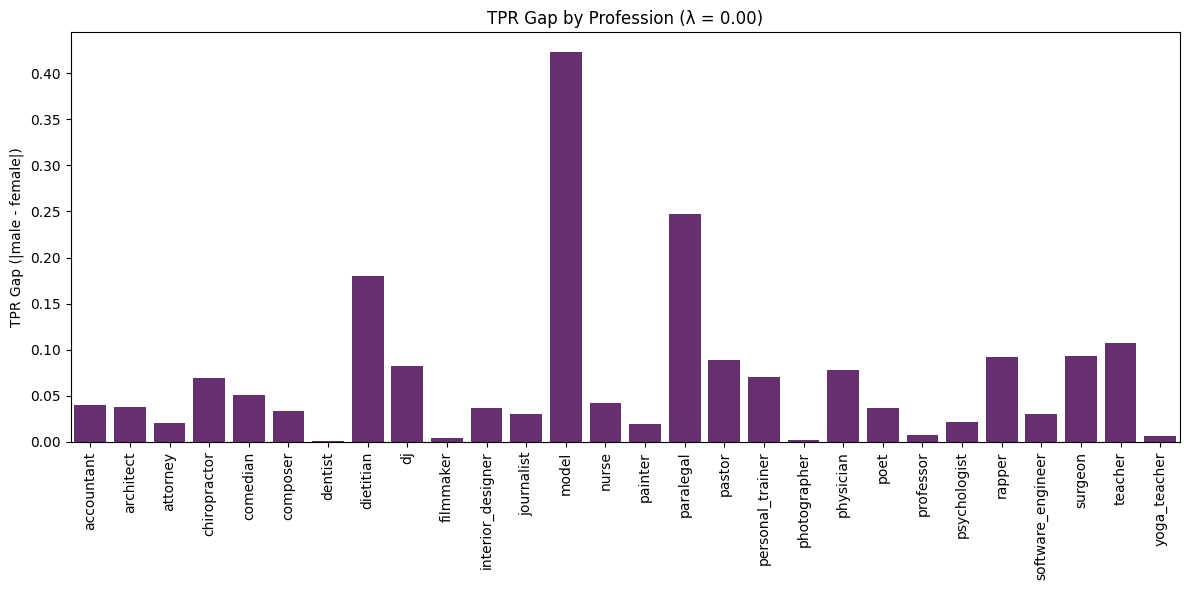

In [ ]:
# SINGLE PLOTTING
import matplotlib.pyplot as plt
import seaborn as sns

label_names = test_dataset.labels
adv_result = log_confusion_and_fairness(model, test_loader, device)

TPR_female,▁
TPR_gap,▁
TPR_gap/accountant,▁
TPR_gap/architect,▁
TPR_gap/attorney,▁
TPR_gap/chiropractor,▁
TPR_gap/comedian,▁
TPR_gap/composer,▁
TPR_gap/dentist,▁
TPR_gap/dietitian,▁
TPR_gap/dj,▁


wandb: Downloading large artifact joint_model_adv_0.75:v0, 139.56MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:3.0 (46.4MB/s)


/content/artifacts/joint_model_adv_0.75:v0
TPR (male): 0.7547, TPR (female): 0.7709, GAP: 0.0162


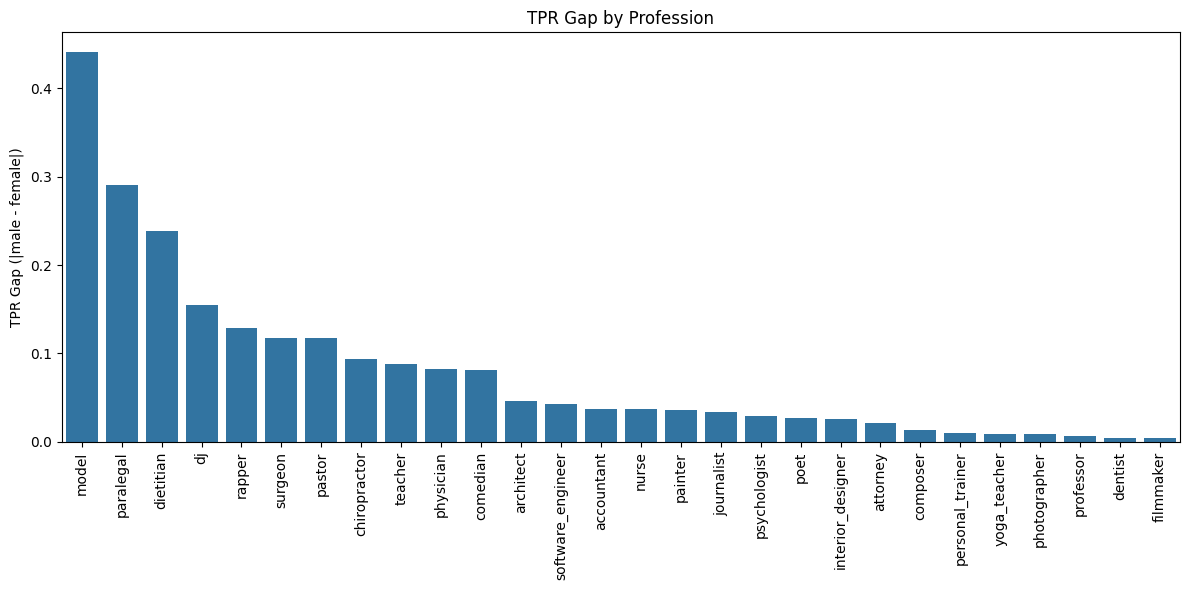

In [ ]:
# ## =========== 0.75 SINGLE PLOTTING ============ ##
# import wandb
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Initialize a new W&B run
# run = wandb.init()
# artifact = run.use_artifact('kina19131-ibm/GRUclf_Adv_0615_night/joint_model_adv_0.75:v0', type='model')
# artifact_dir = artifact.download()


# # Instantiate models
# num_classes = len(set(test_dataset.labels))
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = GRUClassifier(
#     vocab_size=len(vocab),
#     embed_dim=100,
#     hidden_dim=128,
#     num_classes=num_classes
# ).to(device)

# adversary = Adversary(128).to(device)

# print(artifact_dir)

# # Load state dict
# checkpoint = torch.load(
#     f'{artifact_dir}/adv_0.75_checkpoint.pth',
#     map_location=torch.device('cpu'),
#     weights_only=False
# )

# model.load_state_dict(checkpoint['model'])
# adversary.load_state_dict(checkpoint['adversary'])
# model.eval()
# adversary.eval()

# adv_result_75 = log_confusion_and_fairness(model, test_loader, device)

In [ ]:
## BASELINE
## =========== 0.00 ============ ##
import wandb
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a new W&B run
run = wandb.init()
artifact = run.use_artifact('kina19131-ibm/GRUclf_Adv_0615/joint_model_baseline:v0', type='model')
artifact_dir = artifact.download()


# Instantiate models
num_classes = len(set(test_dataset.labels))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GRUClassifier(
    vocab_size=len(vocab),
    embed_dim=100,
    hidden_dim=128,
    num_classes=num_classes
).to(device)

adversary = Adversary(128).to(device)

print(artifact_dir)

# Load state dict
checkpoint = torch.load(
    f'{artifact_dir}/baseline_checkpoint.pth',
    map_location=torch.device('cpu'),
    weights_only=False
)

model.load_state_dict(checkpoint['model'])
adversary.load_state_dict(checkpoint['adversary'])
model.eval()
adversary.eval()

Test_TPR_gap/accountant,▁
Test_TPR_gap/architect,▁
Test_TPR_gap/attorney,▁
Test_TPR_gap/chiropractor,▁
Test_TPR_gap/comedian,▁
Test_TPR_gap/composer,▁
Test_TPR_gap/dentist,▁
Test_TPR_gap/dietitian,▁
Test_TPR_gap/dj,▁
Test_TPR_gap/filmmaker,▁
Test_TPR_gap/interior_designer,▁


wandb: Downloading large artifact joint_model_baseline:v0, 139.16MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:1.1 (127.1MB/s)


/content/artifacts/joint_model_baseline:v0


Adversary(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


Global TPR (male): 0.7517, TPR (female): 0.7662, GAP: 0.0145

Confusion Metrics Per Profession:
accountant           | Male TPR: 0.763  Female TPR: 0.758  Gap: 0.005
accountant           | TP: 1073  TN: 97100  FP: 560  FN: 336
-------------------------------------------------------
architect            | Male TPR: 0.686  Female TPR: 0.651  Gap: 0.035
architect            | TP: 1714  TN: 95200  FP: 1341  FN: 814
-------------------------------------------------------
attorney             | Male TPR: 0.864  Female TPR: 0.822  Gap: 0.042
attorney             | TP: 6904  TN: 90008  FP: 918  FN: 1239
-------------------------------------------------------
chiropractor         | Male TPR: 0.855  Female TPR: 0.749  Gap: 0.106
chiropractor         | TP: 549  TN: 97817  FP: 588  FN: 115
-------------------------------------------------------
comedian             | Male TPR: 0.794  Female TPR: 0.732  Gap: 0.063
comedian             | TP: 549  TN: 97920  FP: 446  FN: 154
------------------------

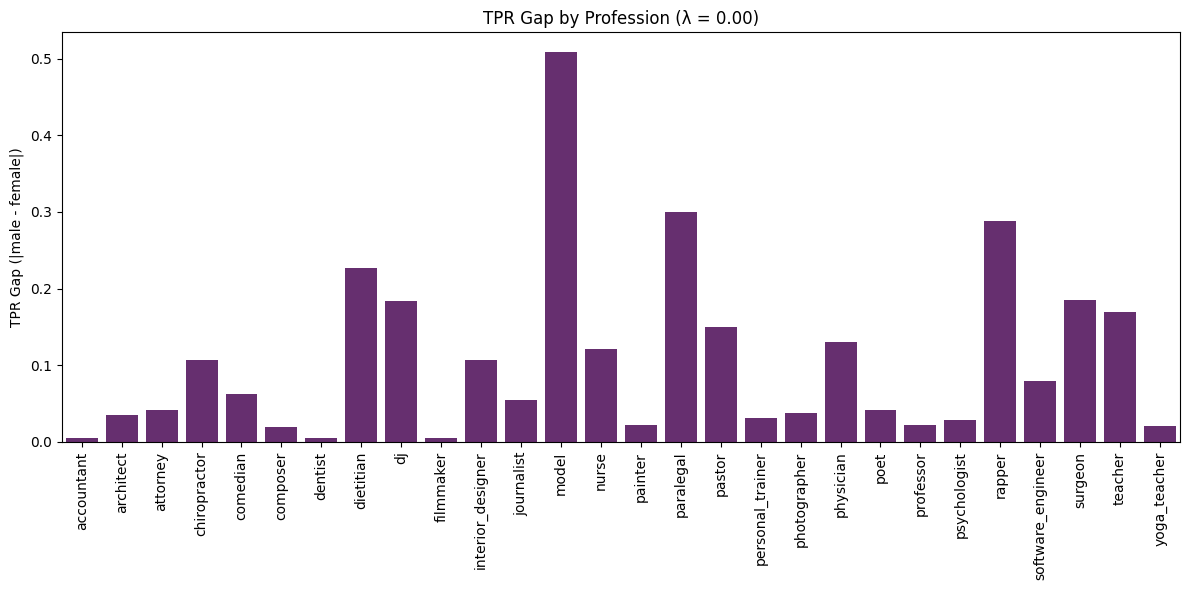

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

baseline_result = log_confusion_and_fairness(model, test_loader, device)

#### put together to compare

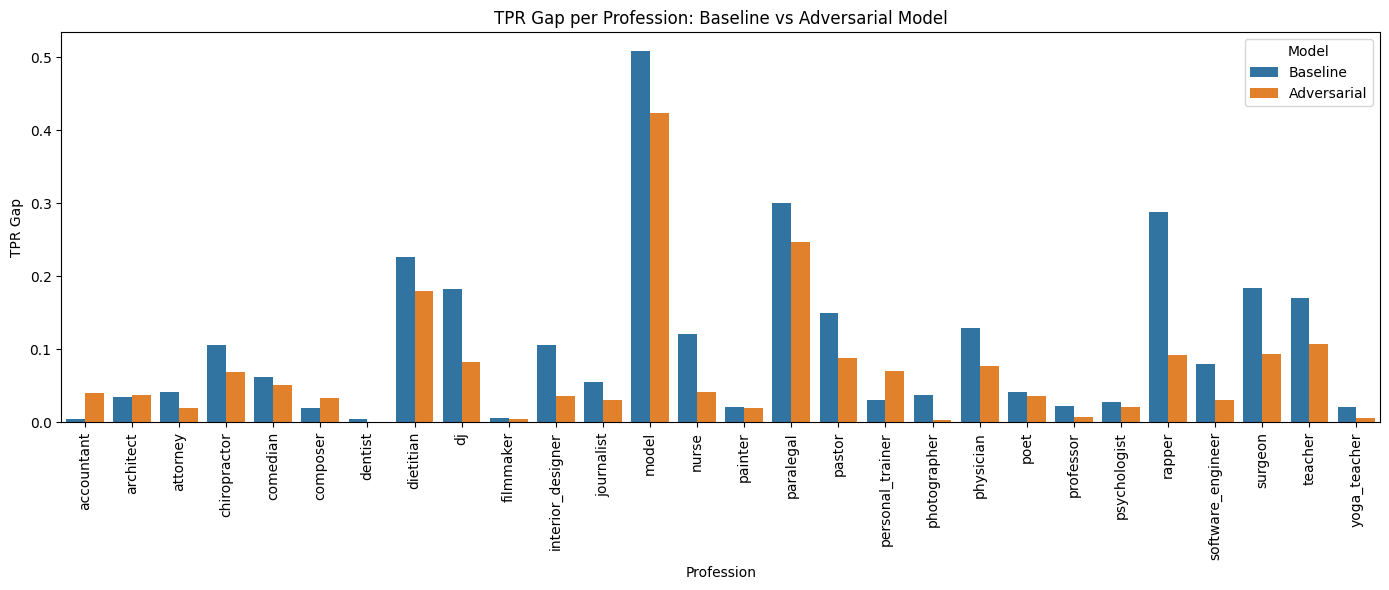

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the two dicts into a DataFrame
baseline_gap = baseline_result["tpr_gap_prof"]
adv_gap = adv_result["tpr_gap_prof"]

df_plot = pd.DataFrame({
    "Profession": list(baseline_gap.keys()),
    "Baseline": [baseline_gap[k] for k in baseline_gap],
    "Adversarial": [adv_gap[k] for k in baseline_gap]
})

df_plot = df_plot.melt(id_vars="Profession", var_name="Model", value_name="TPR Gap")

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x="Profession", y="TPR Gap", hue="Model")
plt.xticks(rotation=90)
plt.title("TPR Gap per Profession: Baseline vs Adversarial Model")
plt.tight_layout()
plt.savefig("compare_tpr_gap_by_profession.pdf")
plt.savefig("compare_tpr_gap_by_profession.png")
wandb.log({"Compare TPR Gap by Profession": wandb.Image("compare_tpr_gap_by_profession.png")})
plt.show()


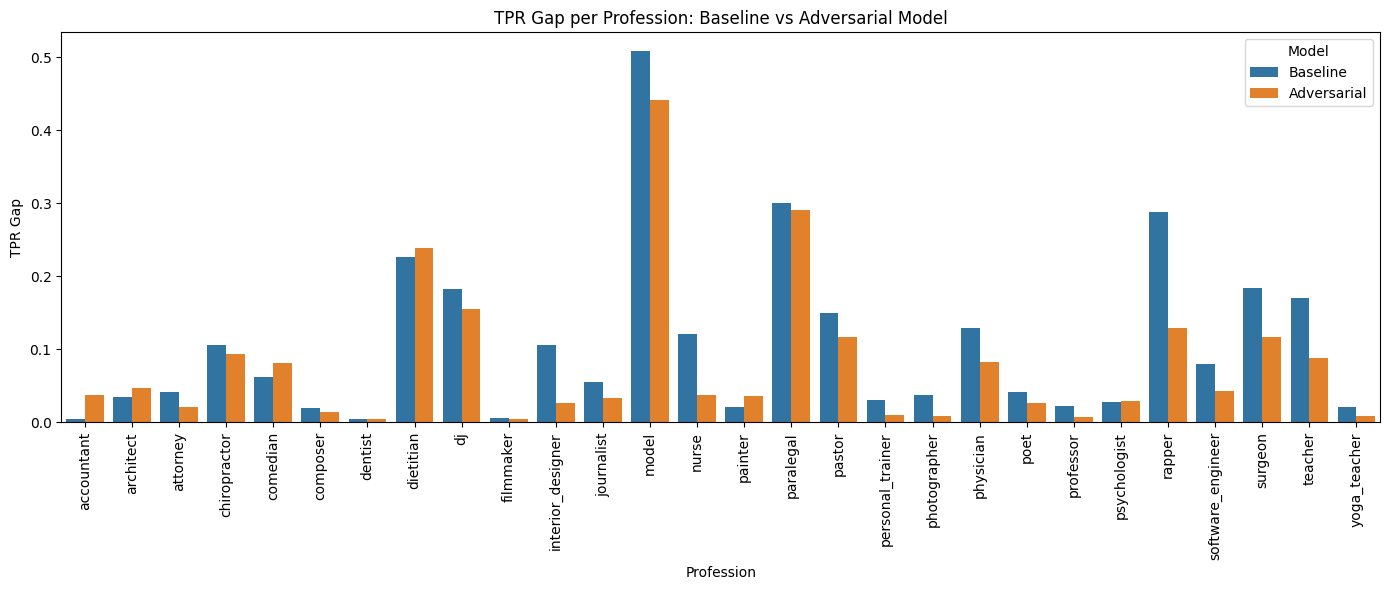

In [ ]:
## LAMBDA = 0.75
# Combine the two dicts into a DataFrame
baseline_gap = baseline_result["tpr_gap_prof"]
adv_gap = adv_result_75["tpr_gap_prof"]

df_plot = pd.DataFrame({
    "Profession": list(baseline_gap.keys()),
    "Baseline": [baseline_gap[k] for k in baseline_gap],
    "Adversarial": [adv_gap[k] for k in baseline_gap]
})

df_plot = df_plot.melt(id_vars="Profession", var_name="Model", value_name="TPR Gap")

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x="Profession", y="TPR Gap", hue="Model")
plt.xticks(rotation=90)
plt.title("TPR Gap per Profession: Baseline vs Adversarial Model")
plt.tight_layout()
plt.savefig("compare_tpr_gap_by_profession.png")
wandb.log({"Compare TPR Gap by Profession": wandb.Image("compare_tpr_gap_by_profession.png")})
plt.show()

### Progression in one lambda gif

Evaluating subset of size 10000

Global TPR (male): 0.7467, TPR (female): 0.7749, GAP: 0.0281

Confusion Metrics Per Profession:
accountant           | Male TPR: 0.795  Female TPR: 0.705  Gap: 0.091
accountant           | TP: 101  TN: 9822  FP:  46  FN:  31
-------------------------------------------------------
architect            | Male TPR: 0.665  Female TPR: 0.609  Gap: 0.056
architect            | TP: 164  TN: 9621  FP: 127  FN:  88
-------------------------------------------------------
attorney             | Male TPR: 0.855  Female TPR: 0.874  Gap: 0.019
attorney             | TP: 694  TN: 9079  FP: 116  FN: 111
-------------------------------------------------------
chiropractor         | Male TPR: 0.900  Female TPR: 0.812  Gap: 0.088
chiropractor         | TP:  76  TN: 9862  FP:  52  FN:  10
-------------------------------------------------------
comedian             | Male TPR: 0.787  Female TPR: 0.789  Gap: 0.003
comedian             | TP:  63  TN: 9876  FP:  44  FN:  17
--

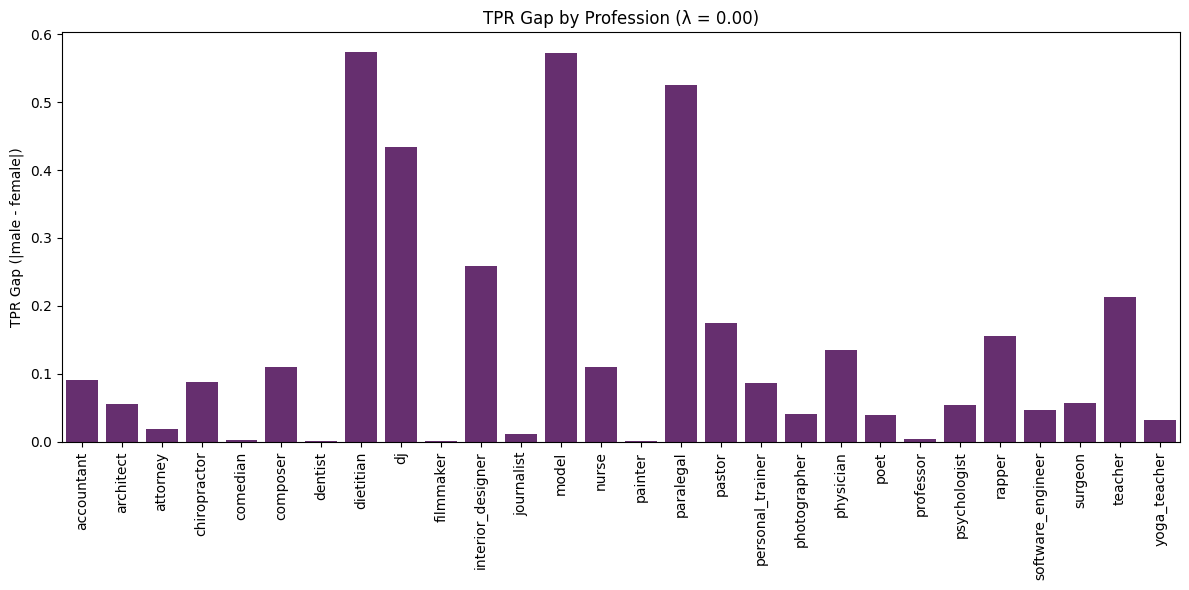

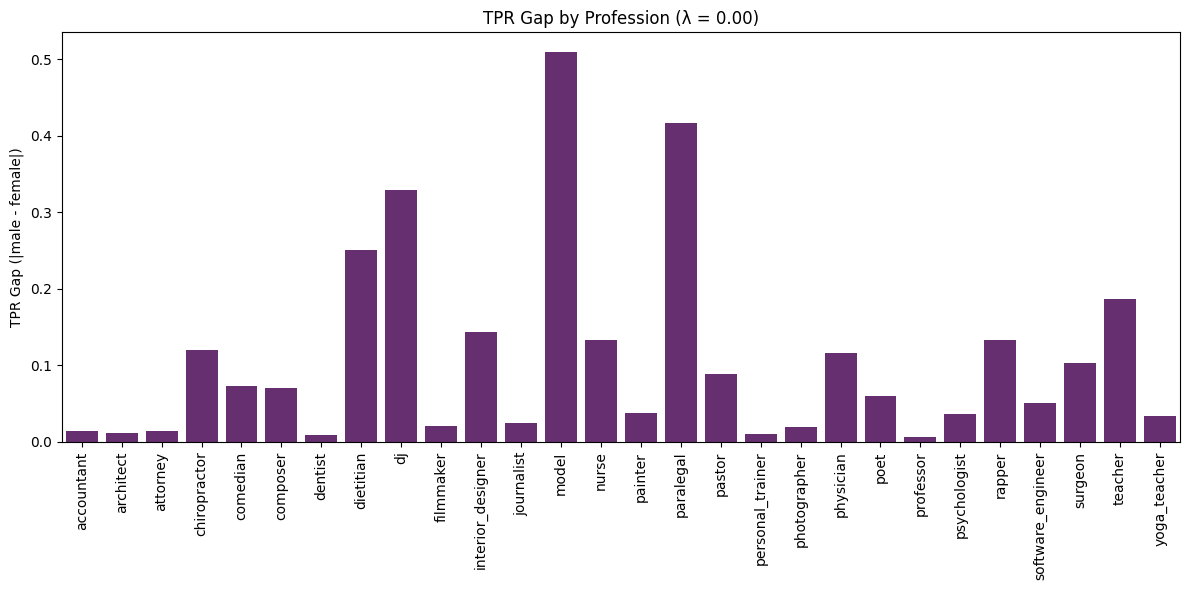

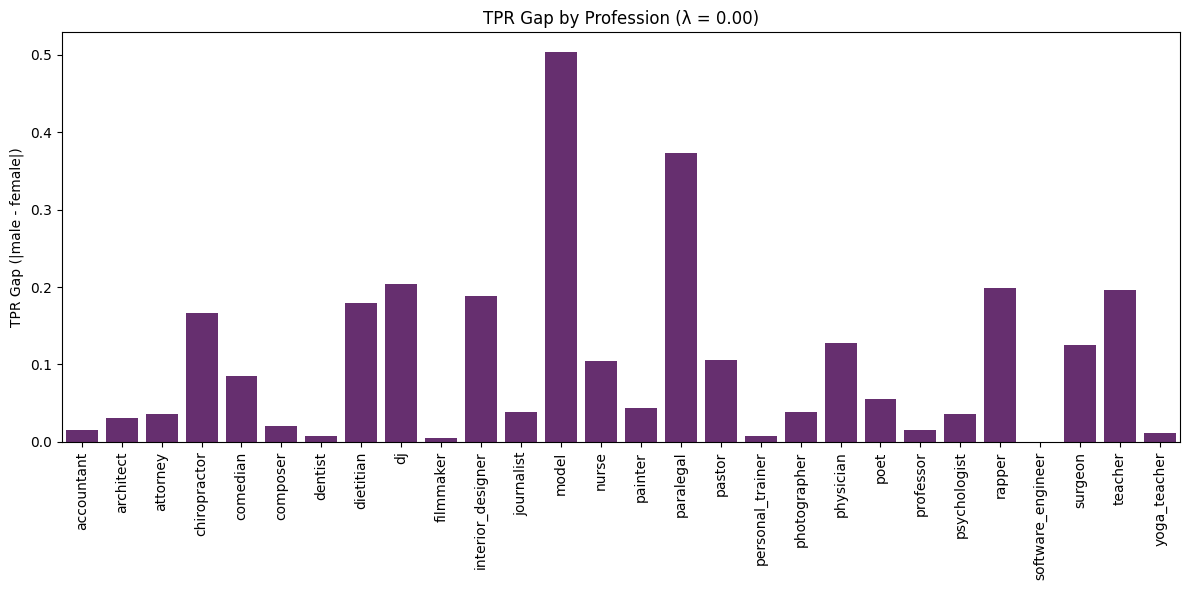

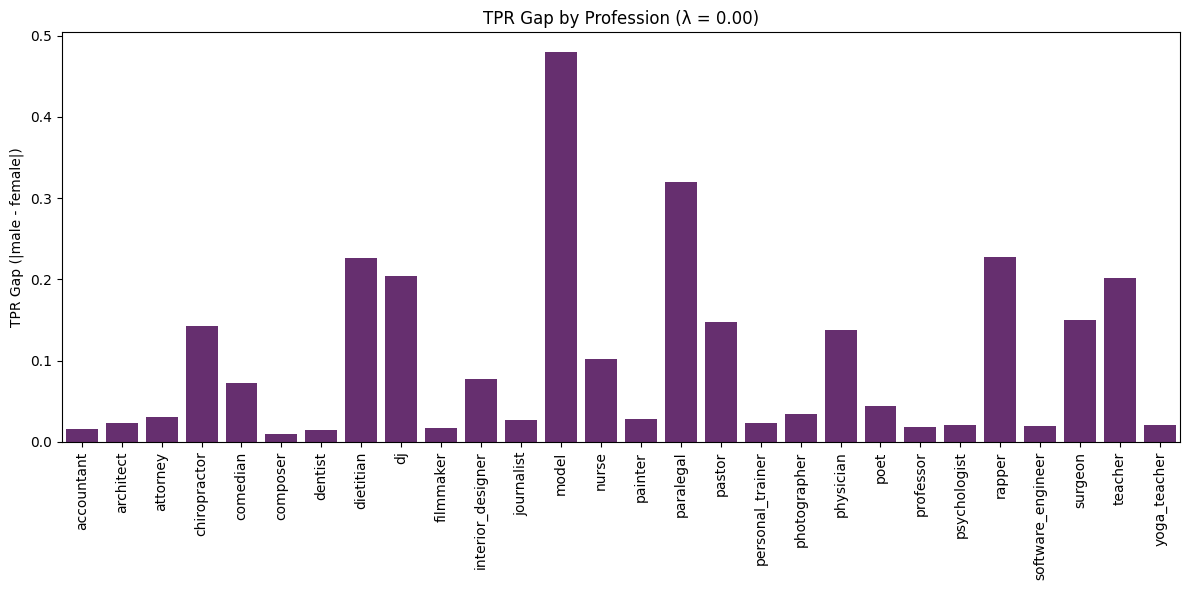

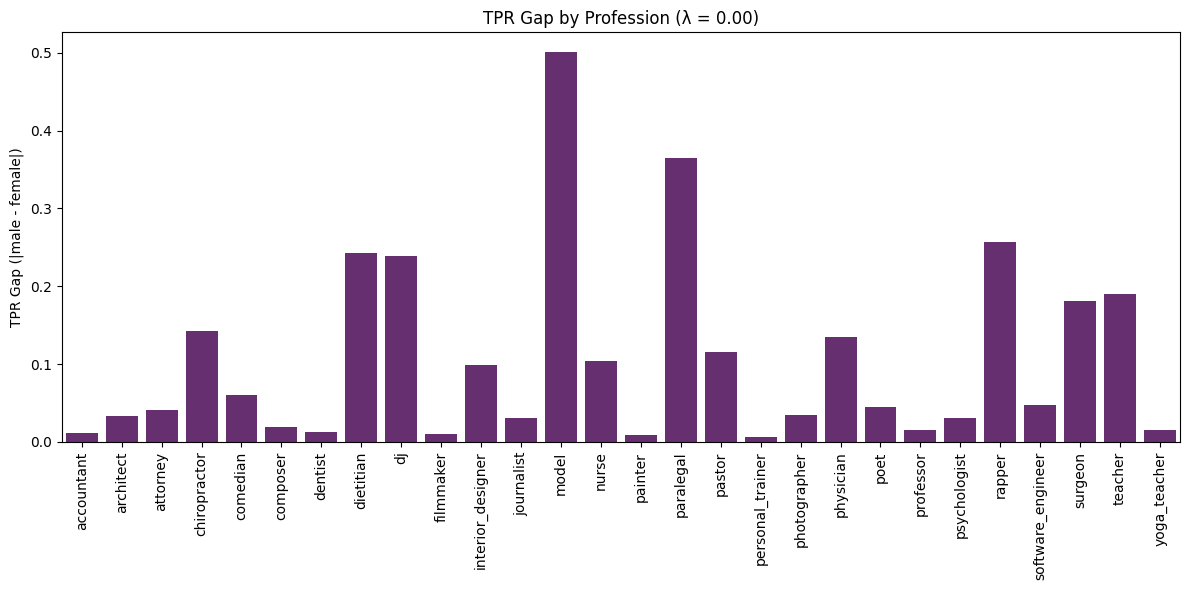

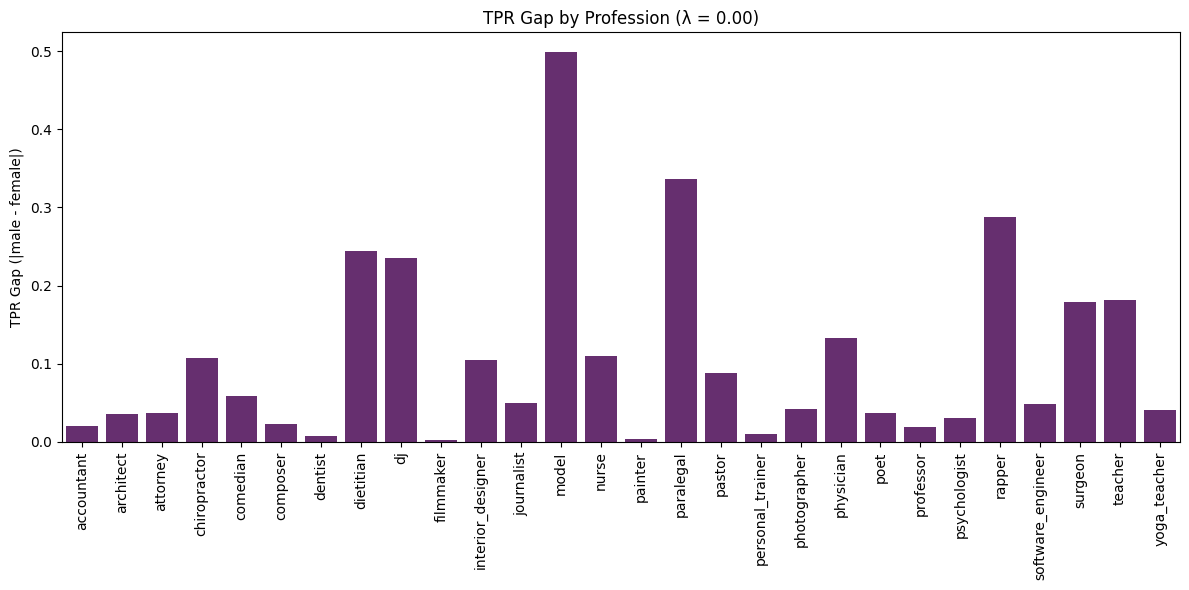

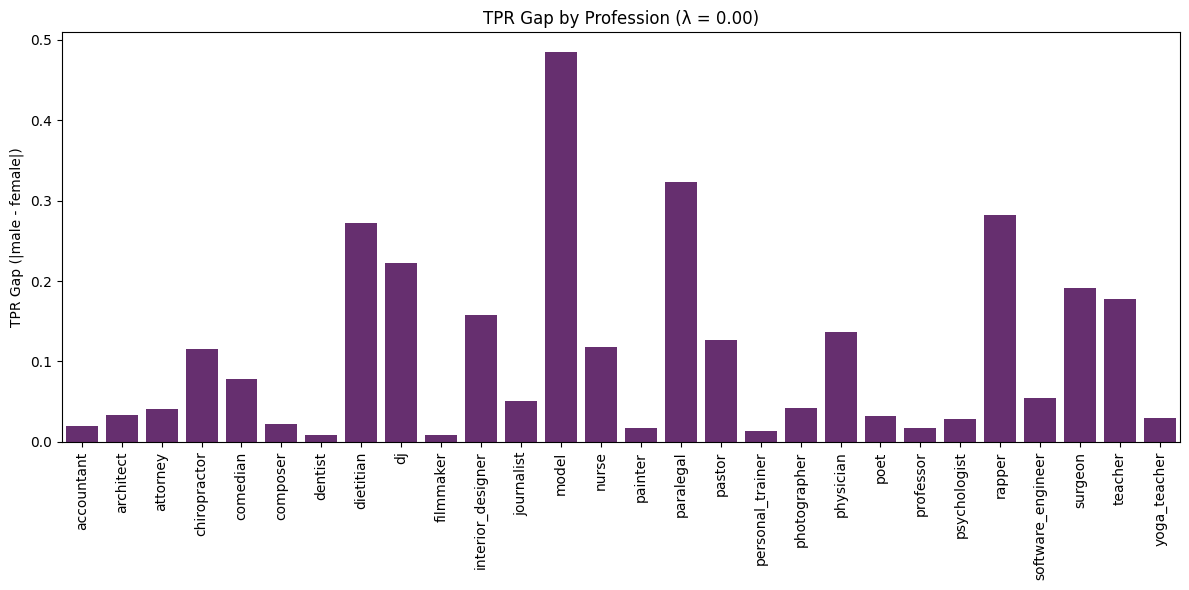

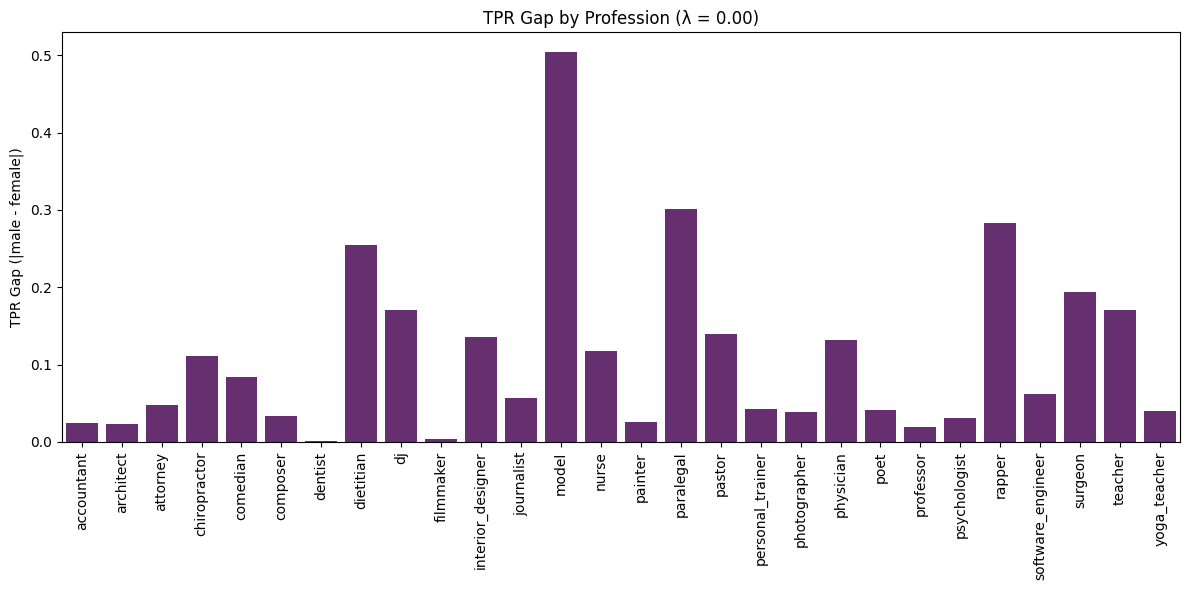

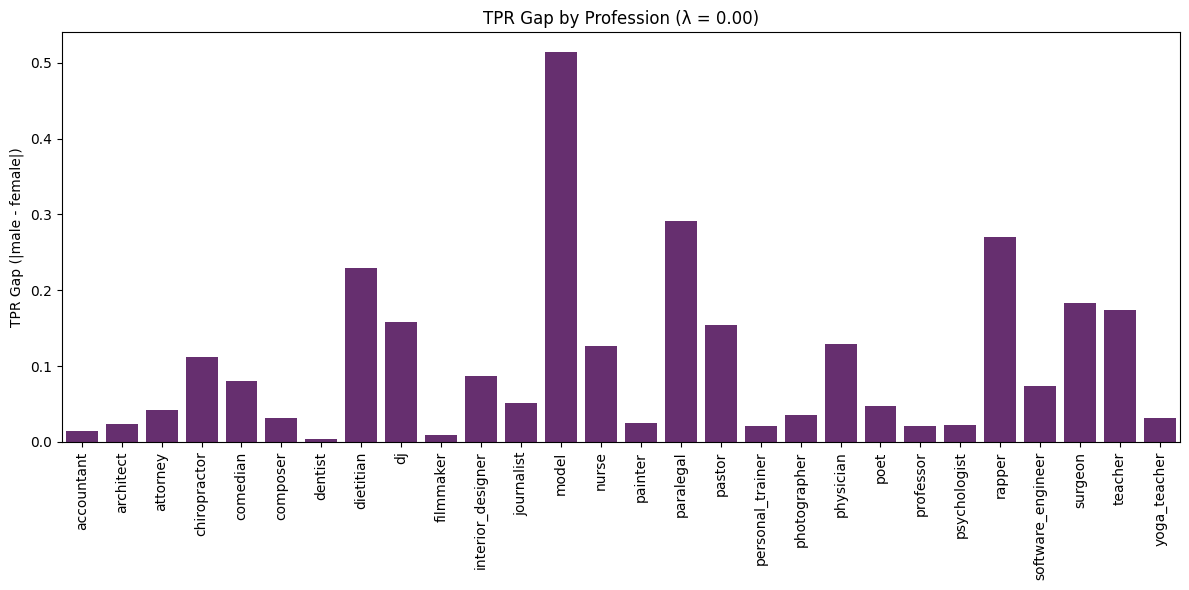

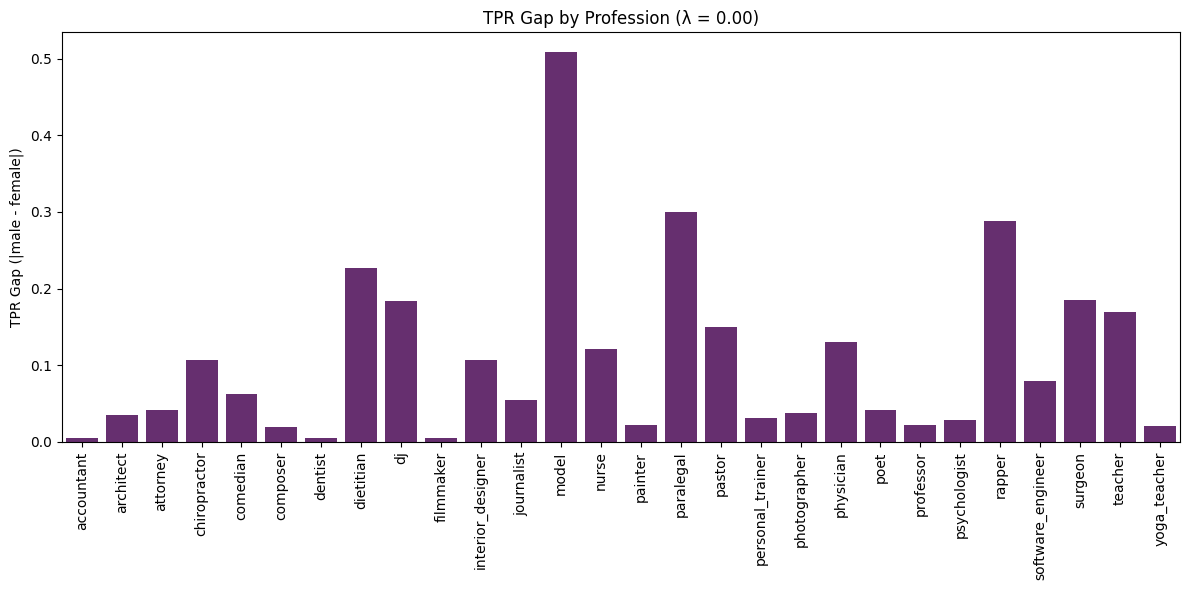

In [ ]:
### IN A LOOP
from torch.utils.data import Subset
import os

os.makedirs("tpr_gap_frames", exist_ok=True)

total_len = len(test_dataset)
step = 10000
num_steps = (total_len + step - 1) // step  # ensures last chunk is included

for i in range(1, num_steps + 1):
    end_idx = min(i * step, total_len)
    subset = Subset(test_dataset, list(range(end_idx)))
    subset_loader = torch.utils.data.DataLoader(subset, batch_size=64, shuffle=False)

    print(f"Evaluating subset of size {end_idx}")
    adv_result = log_confusion_and_fairness(model, subset_loader, device)

    os.rename("tpr_gap_by_profession.png", f"tpr_gap_frames/frame_{i:02d}.png")


In [ ]:
### INTO GIF
import imageio
import glob

# Sort frames in order
image_paths = sorted(glob.glob("tpr_gap_frames/frame_*.png"))
images = [imageio.imread(path) for path in image_paths]

# Save GIF
imageio.mimsave("tpr_gap_evolution.gif", images, duration=1)  # duration = seconds per frame


/tmp/ipython-input-13-2174967615.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(path) for path in image_paths]


### per lambda prediction progression gif


==> Evaluating λ = 0.00


wandb: Downloading large artifact joint_model_baseline:v0, 139.16MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.5 (288.3MB/s)


TPR (male): 0.7517, TPR (female): 0.7662, GAP: 0.0145

==> Evaluating λ = 0.25


TPR_female,▁
TPR_gap,▁
TPR_gap/accountant,▁
TPR_gap/architect,▁
TPR_gap/attorney,▁
TPR_gap/chiropractor,▁
TPR_gap/comedian,▁
TPR_gap/composer,▁
TPR_gap/dentist,▁
TPR_gap/dietitian,▁
TPR_gap/dj,▁


wandb: Downloading large artifact joint_model_adv_0.25:v0, 139.56MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.5 (294.1MB/s)


...

wandb: Downloading large artifact joint_model_adv_0.75:v0, 139.56MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.5 (256.3MB/s)


TPR (male): 0.7547, TPR (female): 0.7709, GAP: 0.0162

==> Evaluating λ = 1.00


TPR_female,▁
TPR_gap,▁
TPR_gap/accountant,▁
TPR_gap/architect,▁
TPR_gap/attorney,▁
TPR_gap/chiropractor,▁
TPR_gap/comedian,▁
TPR_gap/composer,▁
TPR_gap/dentist,▁
TPR_gap/dietitian,▁
TPR_gap/dj,▁


wandb: Downloading large artifact joint_model_adv_1.00:v0, 139.56MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.5 (302.6MB/s)


TPR (male): 0.7511, TPR (female): 0.7680, GAP: 0.0168


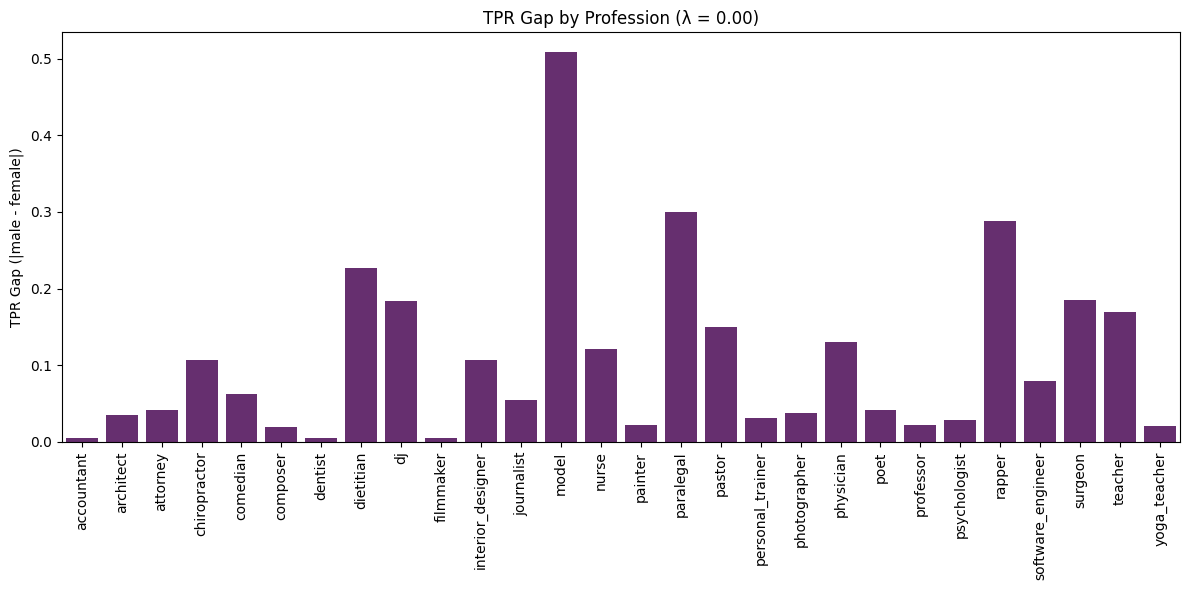

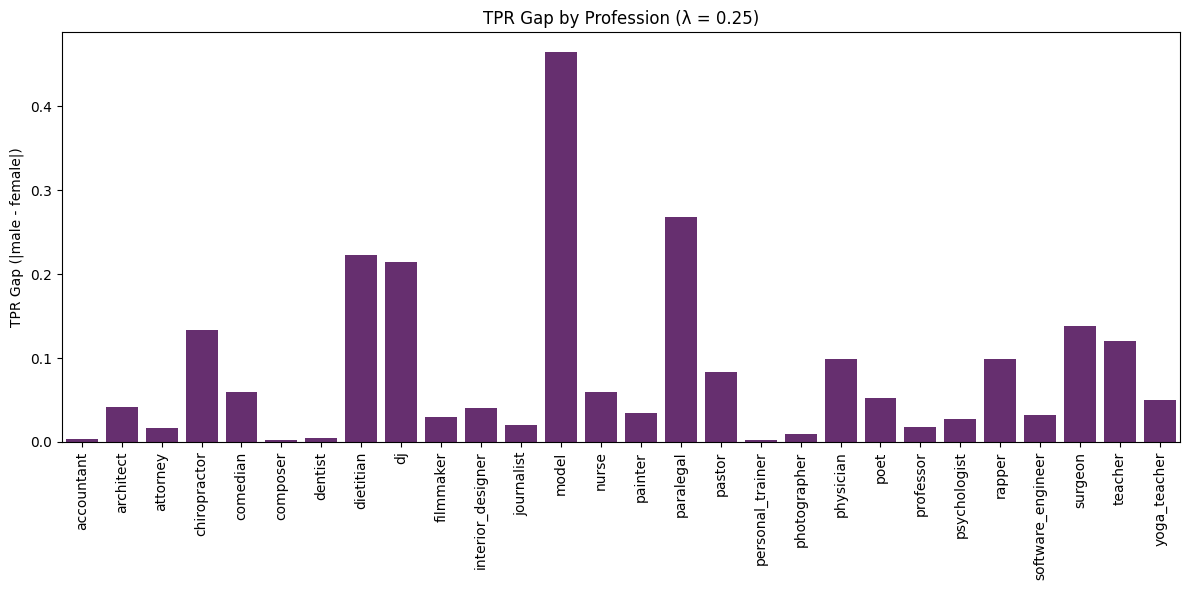

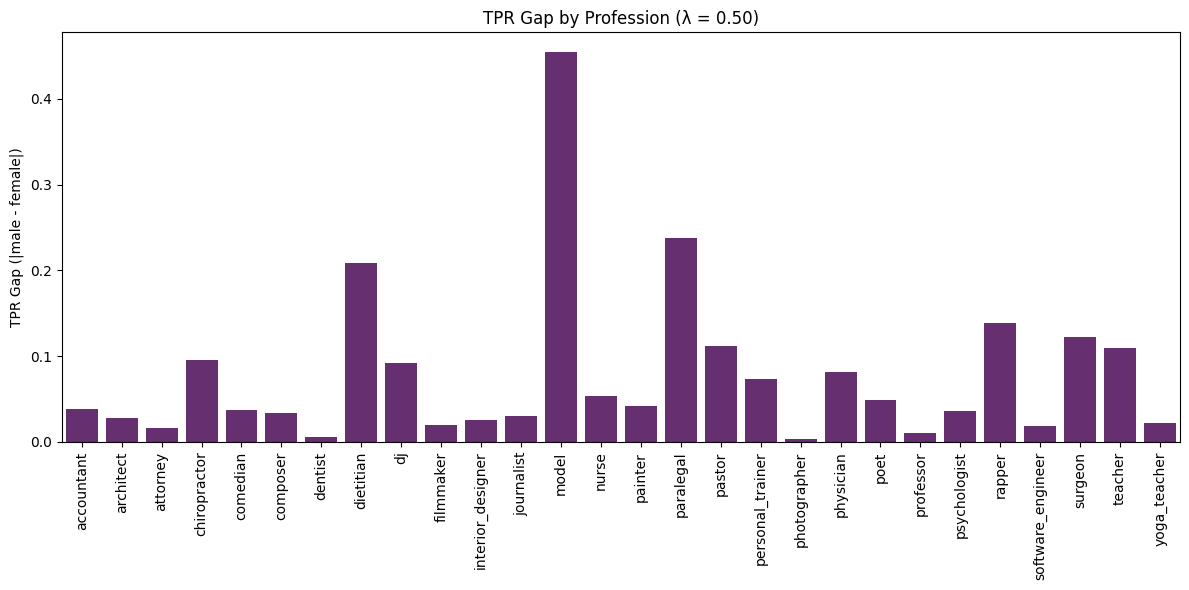

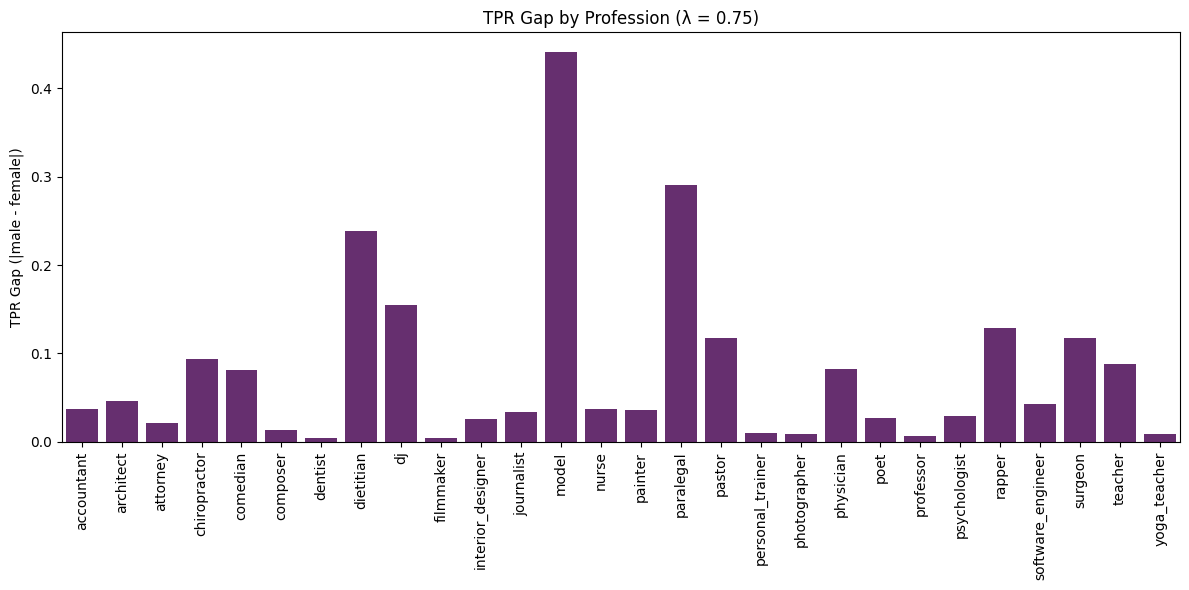

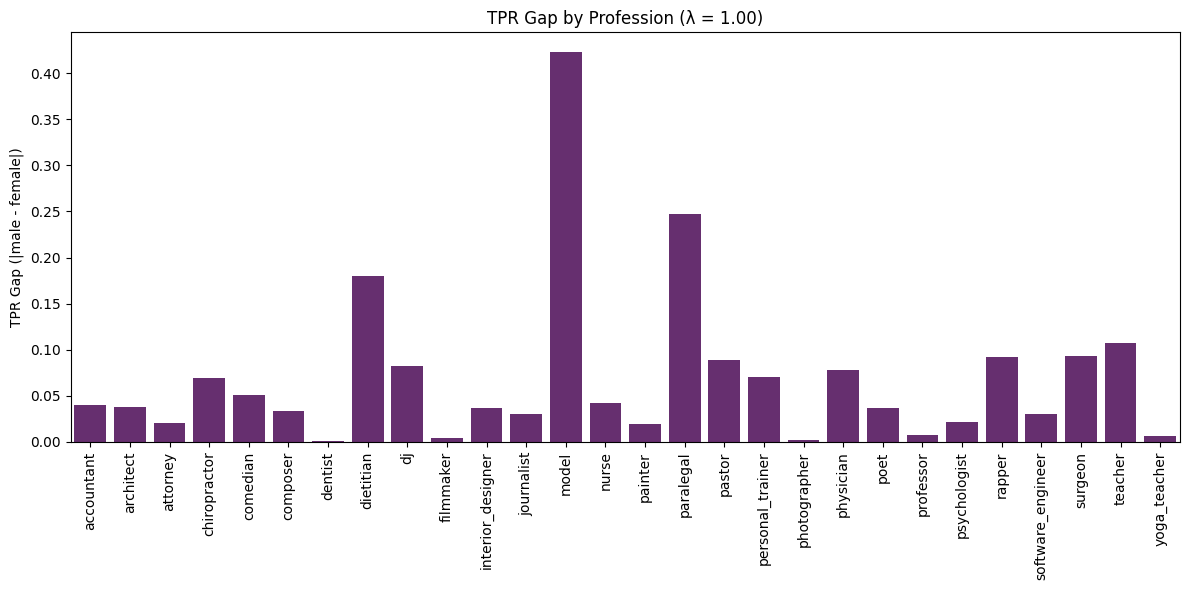

In [ ]:
import os
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(set(test_dataset.labels))

os.makedirs("lambda_gap_frames", exist_ok=True)

lambda_vals = [0.00, 0.25, 0.50, 0.75, 1.00]

for lambda_val in lambda_vals:
    print(f"\n==> Evaluating λ = {lambda_val:.2f}")

    run = wandb.init(project="GRUclf_Adv_0615_night" if lambda_val > 0 else "GRUclf_Adv_0615", reinit=True)

    if lambda_val == 0.00:
        artifact_name = 'kina19131-ibm/GRUclf_Adv_0615/joint_model_baseline:v0'
        ckpt_filename = 'baseline_checkpoint.pth'
    else:
        artifact_name = f'kina19131-ibm/GRUclf_Adv_0615_night/joint_model_adv_{lambda_val:.2f}:v0'
        ckpt_filename = f'adv_{lambda_val:.2f}_checkpoint.pth'

    artifact = run.use_artifact(artifact_name, type='model')
    artifact_dir = artifact.download()
    ckpt_path = Path(artifact_dir) / ckpt_filename

    model = GRUClassifier(
        vocab_size=len(vocab),
        embed_dim=100,
        hidden_dim=128,
        num_classes=num_classes
    ).to(device)

    adversary = Adversary(128).to(device)

    checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(checkpoint['model'])
    adversary.load_state_dict(checkpoint['adversary'])
    model.eval()
    adversary.eval()

    # Evaluate + plot
    result = log_confusion_and_fairness(model, test_loader, device, lambda_val=lambda_val)

    # Rename plot
    os.rename("tpr_gap_by_profession.png", f"lambda_gap_frames/lambda_{lambda_val:.2f}.png")


In [ ]:
import imageio
from PIL import Image


# Collect the frames in sorted order
lambda_vals = [0.00, 0.25, 0.50, 0.75, 1.00]
frame_paths = [f"lambda_gap_frames/lambda_{val:.2f}.png" for val in lambda_vals]
# Load frames as PIL Images (not NumPy arrays)
frames = [Image.open(path).convert("RGB") for path in frame_paths]

# Save as animated GIF with 10s per frame (10000 milliseconds)
frames[0].save(
    "lambda_prediction_evolution_2s.gif",
    save_all=True,
    append_images=frames[1:],
    duration=2000,  # 2 seconds per frame
    loop=0
)

### Keep baseline in gif


==> Evaluating λ = 0.00


wandb: Downloading large artifact joint_model_baseline:v1, 139.16MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:3.5 (39.2MB/s)


TPR (male): 0.7565, TPR (female): 0.7714, GAP: 0.0149

==> Evaluating λ = 0.25


TPR_female,▁
TPR_gap,▁
TPR_gap/accountant,▁
TPR_gap/architect,▁
TPR_gap/attorney,▁
TPR_gap/chiropractor,▁
TPR_gap/comedian,▁
TPR_gap/composer,▁
TPR_gap/dentist,▁
TPR_gap/dietitian,▁
TPR_gap/dj,▁


wandb: Downloading large artifact joint_model_adv_0.25:v0, 139.56MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.5 (289.0MB/s)


...

wandb: Downloading large artifact joint_model_adv_0.75:v0, 139.56MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:3.1 (45.6MB/s)


TPR (male): 0.7547, TPR (female): 0.7709, GAP: 0.0162

==> Evaluating λ = 1.00


TPR_female,▁
TPR_gap,▁
TPR_gap/accountant,▁
TPR_gap/architect,▁
TPR_gap/attorney,▁
TPR_gap/chiropractor,▁
TPR_gap/comedian,▁
TPR_gap/composer,▁
TPR_gap/dentist,▁
TPR_gap/dietitian,▁
TPR_gap/dj,▁


wandb: Downloading large artifact joint_model_adv_1.00:v0, 139.56MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:2.9 (48.0MB/s)


TPR (male): 0.7511, TPR (female): 0.7680, GAP: 0.0168


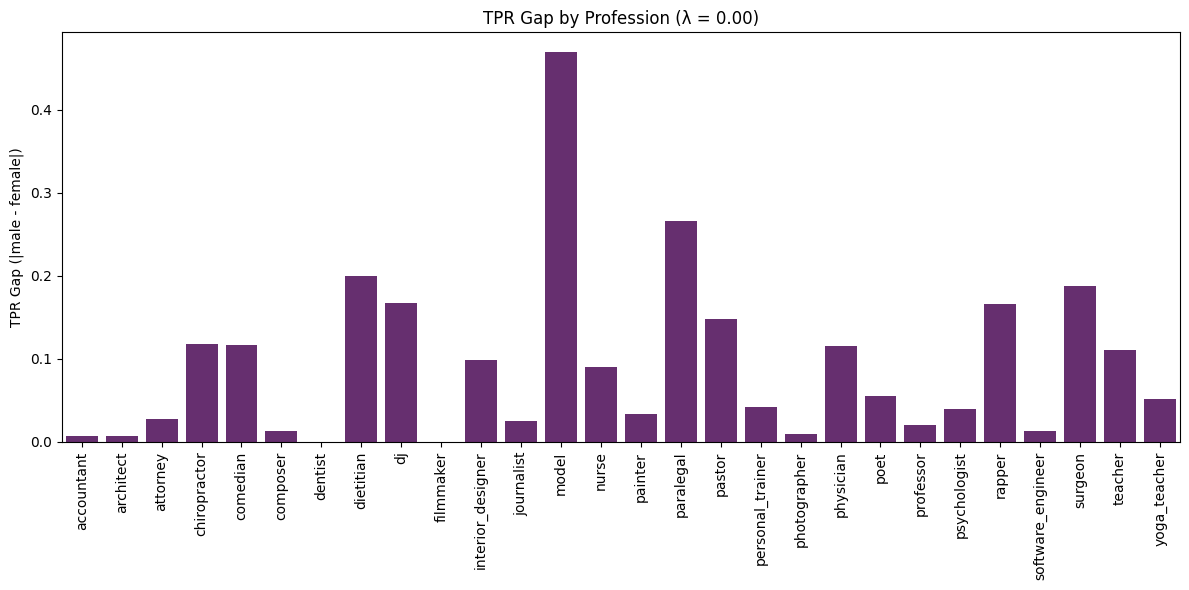

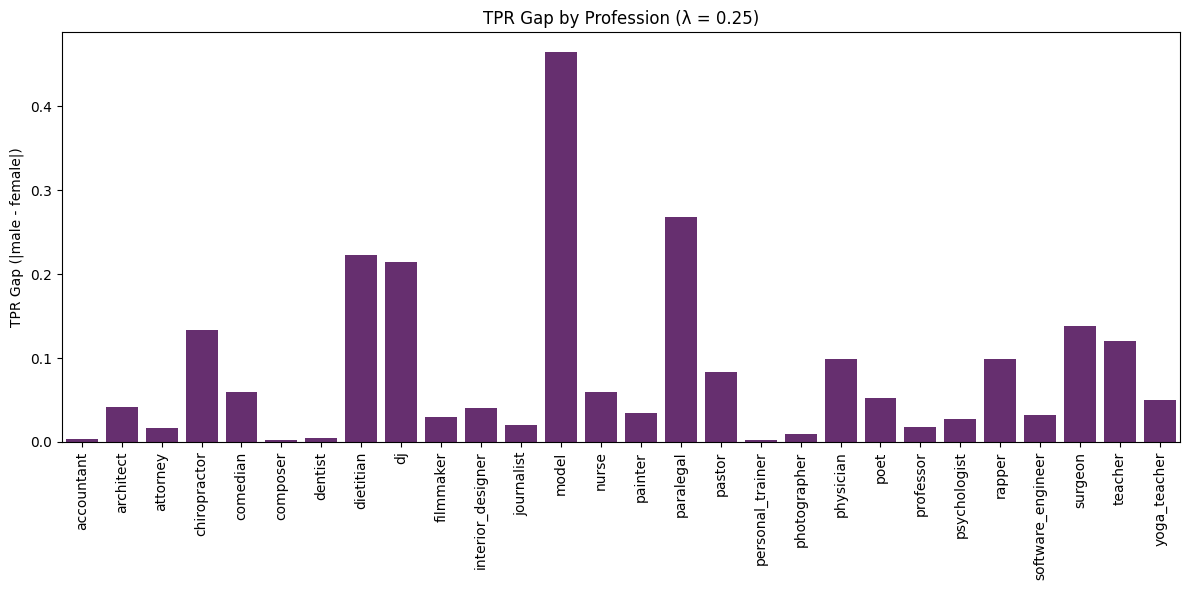

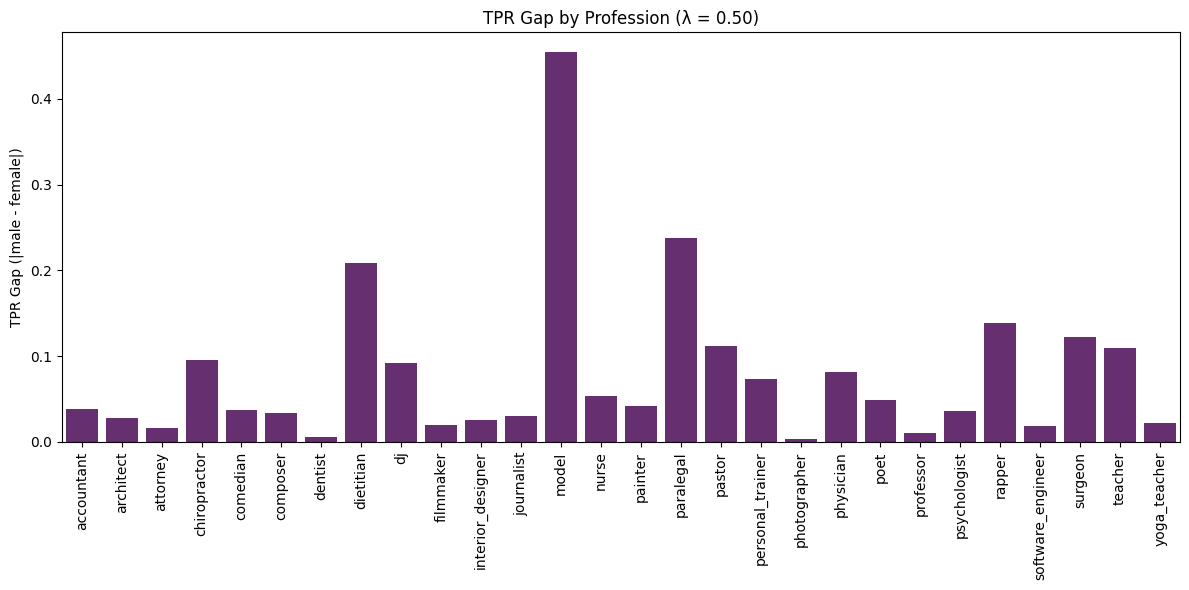

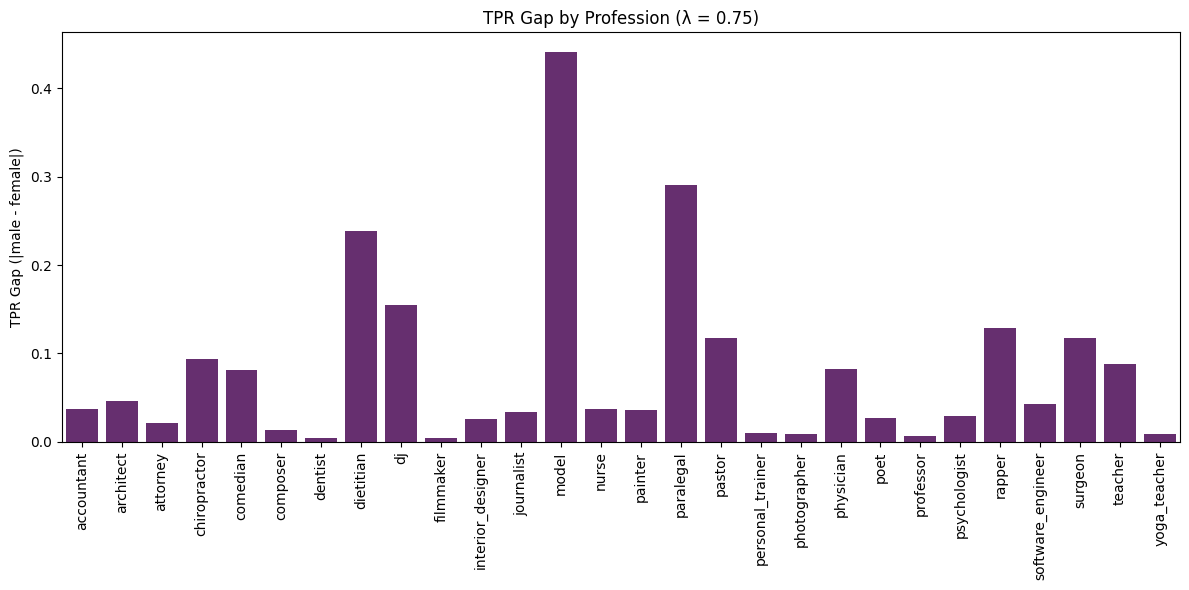

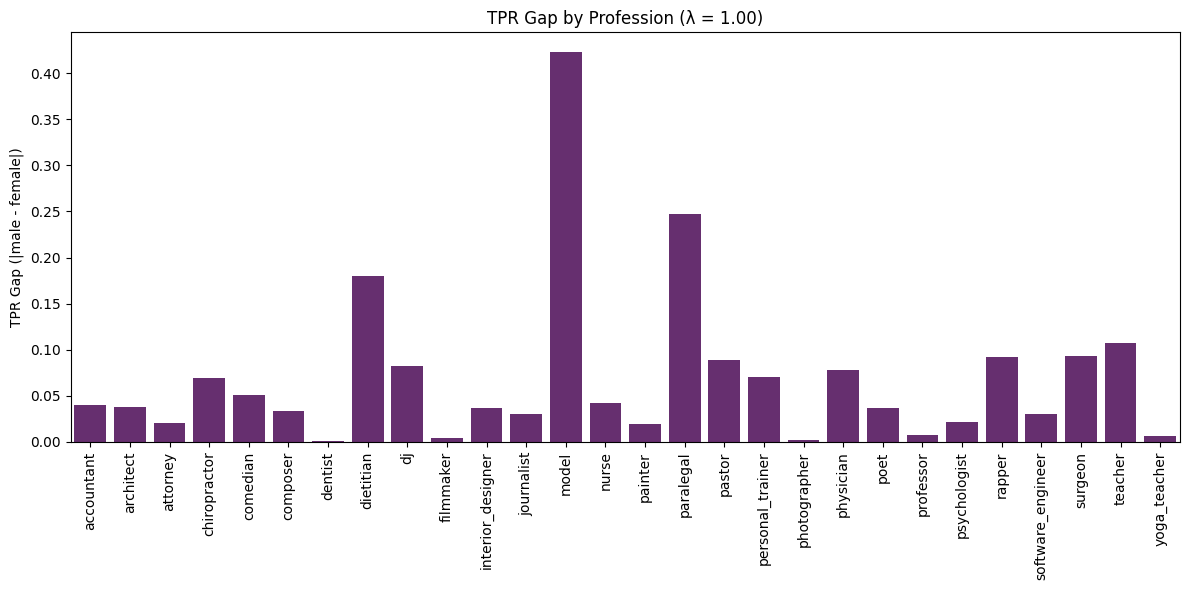

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

os.makedirs("lambda_gap_frames", exist_ok=True)

# Store baseline gaps first
baseline_gaps = None
lambda_vals = [0.00, 0.25, 0.50, 0.75, 1.00]
num_classes = len(set(test_dataset.labels))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# This is your original loop
for lambda_val in lambda_vals:
    print(f"\n==> Evaluating λ = {lambda_val:.2f}")

    run = wandb.init(project="GRUclf_Adv_0615_night", reinit=True)

    if lambda_val == 0.00:
        artifact_name = 'kina19131-ibm/GRUclf_Adv_0615_night/joint_model_baseline:v1'
        ckpt_filename = 'baseline_checkpoint.pth'
    else:
        artifact_name = f'kina19131-ibm/GRUclf_Adv_0615_night/joint_model_adv_{lambda_val:.2f}:v0'
        ckpt_filename = f'adv_{lambda_val:.2f}_checkpoint.pth'

    artifact = run.use_artifact(artifact_name, type='model')
    artifact_dir = artifact.download()
    ckpt_path = Path(artifact_dir) / ckpt_filename

    model = GRUClassifier(
        vocab_size=len(vocab),
        embed_dim=100,
        hidden_dim=128,
        num_classes=num_classes
    ).to(device)

    adversary = Adversary(128).to(device)

    checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(checkpoint['model'])
    adversary.load_state_dict(checkpoint['adversary'])
    model.eval()
    adversary.eval()

    # Get TPR results
    result = log_confusion_and_fairness(model, test_loader, device, lambda_val=lambda_val)
    current_gaps = result["tpr_gap_prof"]

    # For plotting: ensure consistent profession order
    profession_order = [id2profession[i] for i in range(len(id2profession))]
    current_gaps_complete = {prof: current_gaps.get(prof, 0.0) for prof in profession_order}

    if lambda_val == 0.00:
        baseline_gaps = current_gaps_complete  # Save for later
        continue  # Don't create a frame for baseline alone

    # Plot both baseline and current gaps
    plt.figure(figsize=(12, 6))

    # Plot baseline (in light purple)
    sns.barplot(
        x=list(baseline_gaps.keys()),
        y=list(baseline_gaps.values()),
        order=profession_order,
        color="#9E66D0",
        label="λ = 0.00 (Baseline)"
    )

    # Plot current lambda overlay (dark purple)
    sns.barplot(
        x=list(current_gaps_complete.keys()),
        y=list(current_gaps_complete.values()),
        order=profession_order,
        color="#6D247A",
        alpha=0.8,
        label=f"λ = {lambda_val:.2f}"
    )

    plt.xticks(rotation=90)
    plt.ylabel("TPR Gap (|male - female|)")
    plt.title(f"TPR Gap by Profession\nBaseline vs λ = {lambda_val:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"lambda_gap_frames/lambda_{lambda_val:.2f}.png")
    plt.close()


In [ ]:
from PIL import Image

lambda_vals = [0.25, 0.50, 0.75, 1.00]  # Only the overlaid frames

frame_paths = [f"lambda_gap_frames/lambda_{val:.2f}.png" for val in lambda_vals]
frames = [Image.open(p).convert("RGB") for p in frame_paths]

frames[0].save(
    "lambda_prediction_evolution_w_baseline_a.gif",
    save_all=True,
    append_images=frames[1:],
    duration=2000,
    loop=0
)

In [ ]:
'''
Interpret the numbers
Typical language in a report / notebook:

The adversarially-trained GRU reduces the global TPR gap from 0.187 → 0.089 (-52 %), and lowers per-profession gaps for 23 / 28 occupations.
A fresh linear probe’s gender-prediction accuracy falls from 91 % on the baseline to 54 % on the adversarial model—close to random guessing—indicating the hidden representation no longer encodes gender strongly. Meanwhile, task accuracy remains essentially unchanged (78 % → 77 %).

That single paragraph plus the two plots is usually enough to convince reviewers or managers.
'''

'\nInterpret the numbers\nTypical language in a report / notebook:\n\nThe adversarially-trained GRU reduces the global TPR gap from 0.187 → 0.089 (-52 %), and lowers per-profession gaps for 23 / 28 occupations.\nA fresh linear probe’s gender-prediction accuracy falls from 91 % on the baseline to 54 % on the adversarial model—close to random guessing—indicating the hidden representation no longer encodes gender strongly. Meanwhile, task accuracy remains essentially unchanged (78 % → 77 %).\n\nThat single paragraph plus the two plots is usually enough to convince reviewers or managers.\n'

Decoupling adv. from clf optimizer
- only train the adv. on its own gradient
- reverse gradient for encoder updates without optimizing the adversary again


In [ ]:
'''
# Step 1: Train adversary to classify gender
h = h.detach()  # freeze encoder gradient
gender_logits = adversary(h)
adv_loss = adv_criterion(gender_logits, genders)
adv_loss.backward()
adv_optimizer.step()

# Step 2: Train encoder + classifier to minimize label loss and confuse adversary
clf_optimizer.zero_grad()
logits, h = model(input_ids)
clf_loss = clf_criterion(logits, labels)
rev_h = grad_reverse(h, lambda_adv)
adv_logits = adversary(rev_h)
adv_loss = adv_criterion(adv_logits, genders)
loss = clf_loss + adv_loss
loss.backward()
clf_optimizer.step()
'''